<a href="https://colab.research.google.com/github/oscarserc/TESIS/blob/main/PASO_3e___VideoTRANSFORMERS_28x28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**UTILIZACIÓN DE TÉCNICAS DE APRENDIZAJE AUTOMÁTICO PARA LA DETECCIÓN DE ACOSADORES EN UNA RED SOCIAL**.

La base de datos que emplearemos puede llegar a unas 12.000 observaciones. El tamaño crece rápidamente. Por ejemplo 4000 observaciones son aproximadamente 50 MB.

· Pruebas iniciales con: 4.000 observaciones

· Para ello generamos una 100 **simulaciones**, y guardamos unos 40 **frames** de cada una de ellas

· Además como **target** guardamos la matriz con la IDENTIDAD de todos y cada uno de los AGENTES.



#**PRUEBA 5**: Utilizaremos la Arquitectura <font color='green'>**TRANSFORMER (Video Transformer)**</font>.

#Planteamos el problema de localizar a los agentes <b>acosadores</b> como un problema de **Segmentación** de imágenes. (Cada pixel corresponde a un agente y ha de ser clasificado en uno de los tipos que se han definido).





#**TRANSFORMERS**.
Este tipo de arquitectura neuronal está especialmente diseñada para el análisis de secuencias, y se originó en el área de Aprendizaje de Lenguaje Natural (NLP - *Natural Language Processing*). Todos los modelos del lenguaje avanzados (LLM - *Large Language Models*), como ChatGPT por poner un ejemplo, están basados en este tipo de arquitectura.

<br></br>

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Estructura_Transformer_1b.png?raw=true' width="650"/>
<figcaption>fig. 1: Esquema de la arquitectura Transformer (aparece la estructura completa formada por un ENCODER y un DECODER) . El bloque gris que engloba el mecanismo de atención y la FCNN se puede apilar N veces, para procesar secuencialmente la señal: la salida del primer bloque pasa al segundo y así sucesivamente. (Adaptado de <font color='blue'>[Vasgani, A. et al. (2023)]). </font></figcaption></center>
</figure>

<br></br>

Si estudiamos la forma en que está diseñado, podemos detectar una primera
capa de procesamiento que es el ENCODER. Su utilidad reside en lograr
una representación sensible al contexto de la secuencia de INPUTS que recibe.
Básicamente consiste en asociar a cada fragmento de información (token) una
proyección (embedding) en un espacio de alta dimensionalidad, de tal manera
que elementos similares tengan unas coordenadas parecidas y estén próximos
entre sí. Esto se traduce en capturar el significado de la información de
entrada.
Posteriormente los datos son procesados por un DECODER, que es el encargado
del aprendizaje de la tarea concreta que se desea desarrollar en el
transformer.


<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Encoder_1f_Cuadros_mas_claros.png?raw=true' width="650"/>
<figcaption>fig. 2: Esquema del mecanismo de atención del Transformer. Entre sus características tenemos que es facilmente paralelizable. </font></figcaption></center>
</figure>

<br></br>

La arquitectura del transformer le permite analizar
secuencias de información muy largas e interiorizar dependencias
con una estructura muy compleja.
Esta característica es muy útil con cierto tipo de información
como es el lenguaje natural (NLP - Natural Language Processing).
Su origen se encuentra en este área de investigación, que es de
donde partió, aunque se uso se ha extendendido a otros campos (como la
visión por computadora) con resultados satisfactorios.

Estructura de la Arquitectura TRANSFORMERS.
<font color='blue'>[Vasgani, A. et al. (2023)]</font>

Esquema y enlaces de la Arquitectura TRANSFORMERS.
<font color='blue'>[Bahdanau, D. et al (2016)]</font>

<br></br>
<br></br>



#**<font color='brown'>· <u>Transformers Visuales I: ViT</u>.</font>**


Los resultados de tratamiento de secuencias se acabaron de trasladar al procesamiento de imágenes.

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Visual_Transformer_1a.png?raw=true' width="650"/>
<figcaption>fig. 3: Esquema de la arquitectura Visual Transformer (ViT) <font color='blue'>[Dosovitskiy, A. et al. (2021)] </font></figcaption></center>
</figure>

<br></br>

Algunos autores han comprobado que las features obtenidas a través de autoentrenamiento de un ViT (visual Transformer) contienen suficiente información explícita como para llevar a cabo directamente la segmentación de las imágenes <font color='blue'>[Caron, M. et al. (2021)]</font>.

Para obtener la variante del Transformer para segmentación de imágenes hemos adaptado la estructura de la arquitectura. El diseño final quedaría como se puede comprobar en las figuras 4 y 5.

<br></br>

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Visual_Transformer_1b.png?raw=true' width="950"/>
<figcaption>fig. 4: Esquema de la arquitectura Visual Transformer (ViT) preparada, no para clasificar imágenes <font color='blue'>[Dosovitskiy, A. et al. (2021)] </font>, sino para segmentar imágenes, y adaptada para el propósito de esta Tesis.</figcaption></center>
</figure>

<br></br>

La parte ENCODER del Trasformer, tal y como ha sido programada en la parte de implementación de este Notebook aparece esquematizada a continuación (se han encadenando 3 bloques de procesamiento):

<br></br>

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Encoder_1b.png?raw=true' width="400"/>
<figcaption>fig. 5: Por un lado vemos que hay 2 <b>conexiones residuales</b>, que se encargan de fusionar la señal de entrada con la señal ya procesada. Una bifurcación está antes de entrar en el mecanismo de atención <font color="blue">&#10122;</font>, y la otra antes del procesamiento que lleva a cabo la red completamente conexa <font color="blue">&#10123;</font> (<b>FF - feed forward</b>). El objetivo, junto a la normalización (<i>Add & Norm</i> ), es el de reforzar la señal de manera que no se desvanezca cuando pasa por un número de capas muy grande. Por otro lado el <b>mecanismo de atención</b> (<i>Multi-Head Attention</i> ) es el encargado de aproximar las proyecciones los tokens que estén relacionados entre sí (en este caso elementos de la imagen de partida).</figcaption></center>
</figure>




<br></br>
**Ref**.:

<font color='brown'>[Bahdanau, D. et al (2016)]</font>
*Neural Machine Translation by Jointly Learning to Align and Translate*
https://arxiv.org/pdf/1409.0473

<font color='brown'>[Vasgani, A. et al. (2023)]</font>
*Attention is All You Need* https://arxiv.org/pdf/1706.03762

<font color='brown'>[Dosovitskiy, A. et al. (2021)] </font>
*An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* https://arxiv.org/pdf/2010.11929

<font color='brown'>[Caron, M. et al. (2021)]</font>
*Emerging Properties in Self-Supervised Vision Transformers* https://arxiv.org/pdf/2104.14294






#**<font color='brown'>· <u>Transformers Visuales II: ViViT</u>.</font>**

El siguiente paso consistirá en adaptar la arquitectura TRANSFORMER para poder procesar secuencias de IMAGEN.

Una posible forma de procesamiento de las imágenes para convertirla en una sencuencia 1, 2, . . . , T podría ser la que aparece a continuación.

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Video_1a.png?raw=true' width="750"/>
<figcaption>fig. 6a: Esquema de posibles inputs para procesar VIDEO en un Transformer a) <font color='blue'>[Arnab, A. et al (2021)] </font></figcaption></center>
</figure>

Otra posibilidad planteada sería la siguiente.

<br></br>

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Video_2a.png?raw=true' width="550"/>
<figcaption>fig. 6b: Esquema de posibles inputs para procesar VIDEO en un Transformer b) <font color='blue'>[Arnab, A. et al (2021)] </font></figcaption></center>
</figure>


Mejor explicado.

<br></br>

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Video_3a.png?raw=true' width="850"/>
<figcaption>fig. 6b: Esquema de posibles inputs para procesar VIDEO en un Transformer, y obtención de la proyección de los <b>tokens</b> <font color='blue'>[Kim, N. et al (2022)] </font></figcaption></center>
</figure>


<br></br>
**Ref**.:

<font color='brown'>[Arnab, A. et al (2021)]</font>
*Vivit: A video vision transformer*
https://arxiv.org/pdf/2103.15691

<font color='brown'>[Kim, N. et al (2022)]</font>
*SMaTE: A segment-level feature mixing and temporal encoding framework for facial expression recognition*
https://www.mdpi.com/1424-8220/22/15/5753

<br></br>

#**CARGA DE DATOS**.

###· Procedemos a subir el archivo local: **<font color = "brown">bd_100simulaciones_28x28_emo85_vs_15.csv</font>** a Google COLAB

###· Utilizamos la librería PANDAS para leer el archivo


#CARGA DE DATOS 1 (Base de datos pequeña)

In [ ]:

import pandas as pd

# Cargamos los datos
# ------------------
# Usamos una de ciclos bajos para ver el resultado
bd_simulaciones = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15.csv')
#bd_simulaciones = pd.read_csv('bd_100simulaciones_4000ciclos_LEARN_Pagos_y_Emocion_28x28_emo30_vs_15t_30c_25tft_01.csv')


In [ ]:
import pandas as pd

# Cargamos los datos
# ------------------
#bd_simulaciones = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15.csv')
# En el archivo de: 3000 CICLOS con lambda=0.1, salía error de pandas. Como si faltara un string y saliera ERROR EOF
# Gemini propone añadir: engine='python'
# bd_simulaciones = pd.read_csv('bd_100simulaciones_3000ciclos_LEARN_Pagos_y_Emocion_28x28_emo85_vs_15_01.csv', engine='python')
bd_simulaciones = pd.read_csv('bd_100simulaciones_3000ciclos_LEARN_Pagos_y_Emocion_28x28_emo85_vs_15_01.csv')

# AHORA NO ALEATORIZAMOS. Si vamos a aleatorizar, descomentar la siguiente linea
# ------------------------------------------------------------------------------
#bd_simulaciones = bd_simulaciones.sample(frac=1).reset_index(drop=True)


#CARGA DE DATOS 2 (Base de datos ensamblada) **2 Agentes**

In [ ]:

import pandas as pd

# CARGAMOS LA BASE DE DATOS SIN PERMUTAR LAS FILAS (grid de 28x28, y población 85-15 emocionales/mutantes)
# ------------------------------------------------
bd_simulaciones_1 = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15.csv')
bd_simulaciones_2 = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15_II.csv')
bd_simulaciones_3 = pd.read_csv('bd_100simulaciones_28x28_emo85_vs_15_III.csv')

bd_simulaciones = pd.concat([bd_simulaciones_1, bd_simulaciones_2, bd_simulaciones_3])


#CARGA DE DATOS 2 (Base de datos ensamblada) **4 Agentes**

In [ ]:

import pandas as pd

# CARGAMOS LA BASE DE DATOS SIN PERMUTAR LAS FILAS (grid de 28x28, y población 30-15 emocionales/mutantes)
# junto a 30%  cooperadores y 20% Tit-for-Tat
# ------------------------------------------------
bd_simulaciones_1 = pd.read_csv('bd_100simulaciones_28x28_emo30_vs_15t_30c_25tft.csv')
bd_simulaciones_2 = pd.read_csv('bd_100simulaciones_28x28_emo30_vs_15t_30c_25tft_II.csv')
bd_simulaciones_3 = pd.read_csv('bd_100simulaciones_28x28_emo30_vs_15t_30c_25tft_III.csv')

bd_simulaciones = pd.concat([bd_simulaciones_1, bd_simulaciones_2, bd_simulaciones_3])


#Variables explicativas: **X**

#<font color="blue">NECESITAMOS TRANSFORMAR **X** EN **SECUENCIAS DE 40 FRAMES</font>**

(Procesar las 3 bases de datos juntas, que acumulan 12.000 observaciones tarda 16 minutos) ⏰

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

size       = 28  # <--------------------- LA POBLACIÓN 2 ES DE UN GRID DE 28x28
num_frames = 40
df         = bd_simulaciones.copy()

lista_RGBs         = []
lista_simulaciones = []

X            = []

nombre_columnas_ROJO  = ['r' + str(indice) for indice in range(size*size)]
nombre_columnas_VERDE = ['g' + str(indice) for indice in range(size*size)]
nombre_columnas_AZUL  = ['b' + str(indice) for indice in range(size*size)]

# Iteramos por las 8000 filas de la base de datos de prueba
for fila in range(len(bd_simulaciones)):
  canal_r = pd.array(df[nombre_columnas_ROJO].iloc[fila]).reshape(size,size)
  canal_v = pd.array(df[nombre_columnas_VERDE].iloc[fila]).reshape(size,size)
  canal_a = pd.array(df[nombre_columnas_AZUL].iloc[fila]).reshape(size,size)

  # CUIDADO que np.dstack apila los tres valores de cada pixel
  # ----------------------------------------------------------
  frame = np.array([canal_r, canal_v, canal_a])

  lista_RGBs.append(frame)

  if ((fila+1) % num_frames == 0):
    lista_simulaciones.append(np.array(lista_RGBs))
    lista_RGBs = []


X = np.array(lista_simulaciones)
X.shape


(100, 40, 3, 28, 28)

In [ ]:

bd_simulaciones


,r0,r1,r2,r3,r4,r5,r6,r7,r8,r9,...,b777,b778,b779,b780,b781,b782,b783,Simulacion_ID,Frame,Target
0,0.666667,0.701176,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.4,0.4,0.2,0.0,0.0,0.0,0.0,1,1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
1,1.000000,1.000000,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.4,0.4,0.2,0.0,0.0,0.0,0.0,1,2,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
2,1.000000,1.000000,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.4,0.4,0.2,0.0,0.0,0.0,0.0,1,3,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
3,0.666667,0.701176,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.4,0.4,0.2,0.0,0.0,0.0,0.0,1,4,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
4,1.000000,1.000000,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.2,...,0.4,0.4,0.2,0.0,0.0,0.0,0.0,1,5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.333333,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100,36,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3996,0.333333,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100,37,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3997,0.333333,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100,38,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3998,0.333333,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100,39,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


#Target: **Y**.

#<font color="blue">AHORA NECESITAMOS CONVERTIR **Y** EN UNA **SECUENCIA DE 40 FRAMES</font>**

In [ ]:

lista_targets            = []
lista_targets_simulacion = []

for fila in range(len(bd_simulaciones)):
  lista_id_agentes = bd_simulaciones.iloc[fila]['Target'].replace('[','').replace(']','')
  target = [int(caracter) for caracter in lista_id_agentes.split(',')]
  target = np.array(target)
  target = target.reshape(size,size)

  # Con los paréntesis  '['  ']' sale de dimensión: (8000, 1, 10, 10)   # <-------------------------- Aquí ajusto la DIMENSIÓN
  #lista_targets.append([target])
  # Si queremos de dimensión: (8000, 10, 10)
  lista_targets_simulacion.append(target)

  if ((fila+1) % num_frames == 0):
    lista_targets.append(np.array(lista_targets_simulacion))
    lista_targets_simulacion = []

Y = np.array(lista_targets)
Y.shape


(100, 40, 28, 28)

Evaluamos el desequilibrio de clases, por si mejora el algoritmo de optimización al usar PESOS

In [ ]:
import torch
import numpy as np

# Contamos casos de cada clase
unique_classes, counts = np.unique(Y.flatten(), return_counts=True)

total_samples = counts.sum()
num_classes = len(unique_classes)

# Class weights (inversamente proporcional a las frecuencias)
# formula: total_samples / (num_classes * class_count)
# -----------------------------------------------------------
class_weights_np = total_samples / (num_classes * counts)

# Convertimos a tensores de PyTorch
# ---------------------------------
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print("Valores class-weights calculados:", class_weights)

Valores class-weights calculados: tensor([0.59, 3.31])


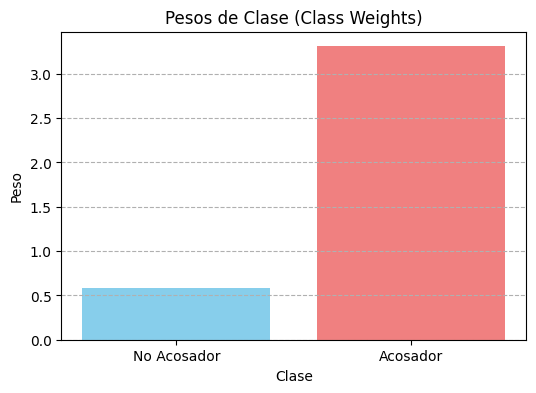

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Convert class_weights tensor to numpy for plotting
class_weights_np = class_weights.numpy()

# Labels for the x-axis
x_labels = ['No Acosador', 'Acosador']

# Create an array for the x-axis positions (e.g., 0, 1)
x_positions = np.arange(len(x_labels))

plt.figure(figsize=(6, 4)) # Optional: Adjust figure size
plt.bar(x_positions, class_weights_np, tick_label=x_labels, color=['skyblue', 'lightcoral'])

plt.xlabel('Clase')
plt.ylabel('Peso')
plt.title('Pesos de Clase (Class Weights)')
plt.grid(axis='y', linestyle='--')
plt.show()


#**CONVERSIÓN EN TENSORES DE PyTorch**.

In [ ]:

import numpy as np
import torch

# PRIMERO TENEMOS QUE EXTRAER LA MATRIX:  X
# y los valores del TARGET:               Y
#
# Luego pasaremos (X, Y) al Dataset que creamos a continuación.
# --------------------------------------------------------------

X_train = X
Y_train = Y

# CREAMOS UNA CLASE PARA LOS DATOS
# ================================

class Dataset_frames(torch.utils.data.Dataset):
  def __init__(self, X, Y):
    # self.X = torch.tensor(X).float()
    self.X = torch.tensor(X).float()
    self.Y = torch.tensor(Y).long()

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    return self.X[ix], self.Y[ix]


# SELECCIONANDO GRUPOS DE OBSERVACIONES PARA VALIDACIÓN
# -----------------------------------------------------

from sklearn.model_selection import train_test_split

X_subset, X_val, Y_subset, Y_val = train_test_split(X_train, Y_train, test_size = 0.2)

dataset = {
    'train' : Dataset_frames(X_subset, Y_subset),
    'val'   : Dataset_frames(X_val, Y_val)
}

dataloader = {
    'train' : torch.utils.data.DataLoader(dataset['train'], batch_size=30,   shuffle=False),
    'val'   : torch.utils.data.DataLoader(dataset['val'],   batch_size=30, shuffle=False)
}



In [ ]:

frames, mascara = next(iter(dataloader['train']))
frames.shape, mascara.shape


(torch.Size([30, 40, 3, 28, 28]), torch.Size([30, 40, 28, 28]))

#**Modelo Vision TRANSFORMER modificado para SEGMENTACIÓN** de imágenes (discriminación inicial de 2 clases).

#· PATCH EMBEDDING

Vamos a proyectar a una dimensión: <font color="green"><b>D=128</b></font>. Tomamos <font color="green"><b>BATCH = 30</b></font>.

In [ ]:

# PROYECCIÓN DE LOS DATOS
# =======================

from einops.layers.torch import Rearrange
import torch.nn as nn
import torch

class PatchEmbedding(nn.Module):
  def __init__(self, img_size, patch_time, patch_size, in_chans, embed_dim):
    super().__init__()
    self.img_size   = img_size                         # (28 x 28) pixeles
    #self.patch_size = patch_size                      # ( 7 x 7 ) pixeles
    self.patch_t    = patch_time                       # 5 fracturas temporales de patch_t = 8 (8*5=40)
    self.patch_h    = patch_size
    self.patch_w    = patch_size
    self.n_patches  = (img_size // patch_size)**2      #        16 patches
    # Dividimos la imagen en patches con una           # (alto: 28 / 7 = 4,
    # convolución                                      # ancho: 28 / 7 = 4 )
    #self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    tubelet_dim = self.patch_t * self.patch_h * self.patch_w * in_chans

    self.to_tubelet_embedding = nn.Sequential(
        Rearrange('b c (t pt) (h ph) (w pw) -> b t (h w) (pt ph pw c)',
                  pt=self.patch_t, ph=self.patch_h, pw=self.patch_w),
        nn.Linear(tubelet_dim, embed_dim)
        )

  def forward(self, x):
    x = self.to_tubelet_embedding(x)
    #x = self.proj(x)
    #x = x.flatten(2)
    #x = x.transpose(1,2)
    return x


# · MULTIHEAD ATTENTION

<font color="red"><b>Observación:</b></font> Introduzco como hiperparámetro predefinido: <font color="green"><b>num_heads=8</b></font>.

<font color="green"><b>Versión que funciona correctamente</b></font>

<br>

In [ ]:

# CONSTRUCTOR recibe:
# -------------------
#   img_size   =  28  (se trata de imágenes de 28 x 28)
#   patch_size =   7  (patch de tamaño 7 x 7)
#   in_chans   =   2  (un canal por imágen, es decir: si se trata en blanco y negro)
#   embed_dim  = 128  (proyectamos en un espacio de 128 dimensiones)
# ----------------------------------------------------------------------------------


# PASAMOS A IMPLEMENTAR: Clase MultiHead Attention
# ================================================

import math

class MultiHeadAttention(nn.Module):
  def __init__(self, n_embd=128, n_heads=8):
    super().__init__()
    self.n_heads = n_heads
    self.n_embd  = n_embd

    # Proyecciones key, query, value
    self.key   = nn.Linear(n_embd, n_embd)       # (128, 128) <- dimensiones
    self.query = nn.Linear(n_embd, n_embd)       # (128, 128)
    self.value = nn.Linear(n_embd, n_embd)       # (128, 128)

    # Proyección salida
    self.proj  = nn.Linear(n_embd, n_embd)

  def forward(self, x):
    B, L, F = x.size()

    # Calculamos los valores: (query, key, values) para todas las cabezas en el lote (batch)
    k =   self.key(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)   #  (B, n_h, T, d_h)
    q = self.query(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)   #  (B, n_h, T, d_h)
    v = self.value(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)   #  (B, n_h, T, d_h)
    # ----------------------------------------------------------------------

    # Mecanismo de atención
    att = (q @ k.transpose(-2, -1))*(1.0 / math.sqrt(k.size(-1))) # (L x nh) * (nh x L) = (L x L)
    att = torch.nn.functional.softmax(att, dim=-1)
    y = att @ v                                                   # (L x L)  * (L x nh) = (L x nh)
                                                                  # -->     queda: (B, d_h, L, nh)
    y = y.transpose(1,2).contiguous().view(B, L, F)               # (B, L, d_h, nh)   --> (B, L, F)

    return self.proj(y)



#· BLOQUE TRANSFORMER

In [ ]:

# BLOQUE TRANSFORMER
# ==================

class TransformerBlock(nn.Module):
  def __init__(self, n_embd, n_heads=8):
    super().__init__()
    # Capa de NORMALIZACIÓN nº 1
    self.ln1  = nn.LayerNorm(n_embd)
    # Capa de NORMALIZACIÓN nº 2
    self.ln2  = nn.LayerNorm(n_embd)
    # CAPA DE ATENCIÓN
    self.attn = MultiHeadAttention(n_embd, n_heads)
    # fully conected layer
    self.mlp  = nn.Sequential(
        nn.Linear(n_embd, 4*n_embd),
        nn.ReLU(),
        nn.Linear(4*n_embd, n_embd)
    )

  def forward(self, x):
    x = x + self.attn(self.ln1(x))
    x = x + self.mlp(self.ln2(x))
    return x



#· BLOQUE OUTPUT
<font color="red"><b>PRUEBA nº 1:</b></font> Intentaré generar las capas de segmentación finales. Se corresponderán con el número output_channels (uno por cada clase en que se prentende clasificar). Para discriminar entre AGENTES EMOCIONALES y AGENTES MUTANTES utilizamos: <b>output_channels = 2</b>. Es decir, hay que generar 2 máscaras al final.


In [ ]:

import torch.nn as nn

# CLASE PARA GENERAR LAS MÁSCARAS DE SEGMENTACIÓN
# ===============================================

# CONSTRUCTOR recibe:
# -------------------
#   img_size    =  28  (se trata de imágenes de 28 x 28)
#   patch_size  =   7  (patch de tamaño 7 x 7)
#   output_dims =   2  (un canal por cada máscara, es decir: clasificación 2 clases)
#   embed_dim   = 128  (proyectamos en un espacio de 128 dimensiones)
# ----------------------------------------------------------------------------------

class OUTPUT_MASKs(nn.Module):
  def __init__(self, image_size, patch_size, embed_dim, output_dims):
    super().__init__()
    self.patch_size  = patch_size
    self.output_dims = output_dims
    self.projection  = nn.Linear(embed_dim, patch_size * patch_size * output_dims)
    self.fold        = nn.Fold(output_size = (image_size, image_size), kernel_size = patch_size, stride = patch_size)

  def forward(self, x):
    B, T, C = x.shape
    x = self.projection(x)
    # -----------------------------------------------------
    # x.shape (B, T, patch_size * patch_size * output_dims)
    # -----------------------------------------------------
    # Plegamos con nn.Fold la última dimensión para que se corresponda con las dimensiones
    # de la imagen de partida (y los correspondientes canales, que serán las máscaras de segmentación)
    x = x.permute(0, 2, 1)
    x = self.fold(x)

    return x


#· Clase Visual Transformer (ViT)

<u>Observar que</u>: <font color='Blue'>[n_classes = 2]</font> es el parámetro para la <b>clasificación de la IMAGEN</b> en uno de los 2 tipos de clases. Hay que introducir una salida para una clasificación binaria (en el caso EMO/TRAIDOR) de todos y cada uno de los píxeles: es decir 2 <b>matrices máscara</b> con el tamaño de la imagen original.

<B>· PRUEBA 🛠</B>:

img_size=28  /  patch_size=7  /  num_patches=16  /  embed_dim=128  /  n_heads=8  

<font color="green"><b>Todo parece funcionar correcto.</b></font>


In [ ]:

# CLASE ViT_Segmentation (Visual Transformer para segmentación)
# =============================================================

# Número de BLOQUES TRANSFORMER   -> n_layers = 3
# Número de CABEZAS (MHAttention) -> n_heads  = 8
# Número de CLASES                -> n_classes = 2
#    por lo tanto necesitamos 2 matrices de dimensiones: img_size x img_size
#    Es decir,                                               (28  x  28)
#    Para luego obtener la predicción con una SOFTMAX.

# ------------------------------------------------
# PONGO DE PRUEBA 4 CLASES que es la que más falla
# ------------------------------------------------

class ViT_Segmentation(nn.Module):
  def __init__(self, img_size=28, patch_time=8, patch_size=7, in_chans=3, embed_dim=128, n_heads=8, n_layers=3,
               n_classes=4, output_dims=4):      # <---------------------------------------------------- PONGO 4 en las dos
    super().__init__()

    self.img_size    = img_size
    self.patch_time  = patch_time
    self.patch_size  = patch_size
    self.in_chans    = in_chans
    self.embed_dim   = embed_dim
    self.n_heads     = n_heads
    self.output_dims = output_dims

    self.patch_embed    = PatchEmbedding(img_size, patch_time, patch_size, in_chans, embed_dim)
    self.pos_embed      = nn.Parameter(torch.zeros(self.patch_embed.n_patches, embed_dim))

    self.layers = nn.Sequential(
        torch.nn.Sequential(*[TransformerBlock(embed_dim, n_heads) for _ in range(n_layers)]),
        OUTPUT_MASKs(img_size, patch_size, embed_dim, output_dims)
    )


  def forward(self, x):
    e = self.patch_embed(x)
    e = e + self.pos_embed
    y = self.layers(e)

    return y


#**MÉTODO para el ENTRENAMIENTO**.
(Probaremos con la subida de los datos a la Tarjeta Gráfica (<b>GPU</b> · <i>Graphics Processing Unit</i> ))

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/GPU_1a.png?raw=true' width="250"/>
<figcaption><font></font></figcaption></center>
</figure>


In [ ]:

from sklearn.metrics import accuracy_score

# Función auxiliar
# ----------------

def softmax(x):
  return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DEFINIMOS LA FUNCIÓN DE ENTRENAMIENTO
# =====================================

def fit(model, dataloader, epochs=10, log_each=1):
   criterion = torch.nn.CrossEntropyLoss()
   optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

   l, acc         = [], []
   val_l, val_acc = [], []

   for e in range(1, epochs+1):
      _l, _acc = [], []
      model.to(DEVICE)                               # <------------------- subimos a la GPU
      model.train()          # <------------------------------------------- *** MODO de TRAINING ***
      for x_b, y_b in dataloader['train']:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)    # <------------------- subimos a la GPU
        y_pred = model(x_b)                          # (No sé si las y_pred hay que subirlas explícitamente)
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_probas = torch.argmax(softmax(y_pred), axis=1)
        # Los SCORES de SKLEARN no aceptan matrices, así que hay que convertirlas en dimensión 1D
        # (usar flatten())
        _acc.append(accuracy_score(y_b.numpy().flatten(), y_probas.detach().numpy().flatten()))

      l.append(np.mean(_l))
      acc.append(np.mean(_acc))
      if not e % log_each:
        print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f}")


      model.eval()            # <------------------------------------------- *** MODO de EVALUACIÓN ***
      _l, _acc = [], []
      with torch.no_grad():
        for x_b, y_b in dataloader['val']:
          x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)   # <------------------- subimos a la GPU
          y_pred = model(x_b)
          loss   = criterion(y_pred, y_b)
          _l.append(loss.item())
          y_probas = torch.argmax(softmax(y_pred), axis=1)
          _acc.append(accuracy_score(y_b.numpy().flatten(), y_probas.numpy().flatten()))
      val_l.append(np.mean(_l))
      val_acc.append(np.mean(_acc))

   return {'epoch':list(range(1,epochs+1)), 'loss':l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}



#**ENTRENAMIENTO DEL MODELO**.


<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/ViViT_1b.png?raw=true' width="850" border="2"/>
<figcaption><font></font></figcaption></center>
</figure>


#<font color="red">Extraemos los volúmenes temporales.</font>

In [ ]:
import math
from einops.layers.torch import Rearrange
import torch.nn as nn
import torch
from sklearn.metrics import accuracy_score
import numpy as np

# --- Auxiliary classes needed for ViT_Segmentation --- #

# Class MultiHead Attention (copied from XELRCPEMTQ3e)
class MultiHeadAttention(nn.Module):
  def __init__(self, n_embd=128, n_heads=8):
    super().__init__()
    self.n_heads = n_heads
    self.n_embd  = n_embd

    # Proyecciones key, query, value
    self.key   = nn.Linear(n_embd, n_embd)
    self.query = nn.Linear(n_embd, n_embd)
    self.value = nn.Linear(n_embd, n_embd)

    # Proyección salida
    self.proj  = nn.Linear(n_embd, n_embd)

  def forward(self, x):
    B, L, F = x.size()

    # Calculamos los valores: (query, key, values) para todas las cabezas en el lote (batch)
    k =   self.key(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)
    q = self.query(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)
    v = self.value(x).view(B, L, F // self.n_heads, self.n_heads).transpose(1,3).transpose(2,3)

    # Mecanismo de atención
    att = (q @ k.transpose(-2, -1))*(1.0 / math.sqrt(k.size(-1)))
    att = torch.nn.functional.softmax(att, dim=-1)
    y = att @ v

    y = y.transpose(1,2).contiguous().view(B, L, F)

    return self.proj(y)

# TransformerBlock (copied from fSG0pzPaYBxM)
class TransformerBlock(nn.Module):
  def __init__(self, n_embd, n_heads=8):
    super().__init__()
    self.ln1  = nn.LayerNorm(n_embd)
    self.ln2  = nn.LayerNorm(n_embd)
    self.attn = MultiHeadAttention(n_embd, n_heads)
    self.mlp  = nn.Sequential(
        nn.Linear(n_embd, 4*n_embd),
        nn.ReLU(),
        nn.Linear(4*n_embd, n_embd)
    )

  def forward(self, x):
    x = x + self.attn(self.ln1(x))
    x = x + self.mlp(self.ln2(x))
    return x

# Updated OUTPUT_MASKs class to handle the temporal dimension correctly for ViViT
class OUTPUT_MASKs(nn.Module):
  def __init__(self, image_size, patch_size, embed_dim, output_dims, num_frames_total, patch_time):
    super().__init__()
    self.patch_size  = patch_size
    self.output_dims = output_dims
    self.image_size = image_size
    self.num_temporal_tubelets = num_frames_total // patch_time # 5
    self.num_spatial_patches_per_frame = (image_size // patch_size)**2 # 16

    self.projection  = nn.Linear(embed_dim, patch_size * patch_size * output_dims)
    self.fold_single_frame = nn.Fold(output_size = (image_size, image_size), kernel_size = patch_size, stride = patch_size)

  def forward(self, x):
    # x comes in as (B, total_patches_flattened, embed_dim), where
    # total_patches_flattened = num_temporal_tubelets * num_spatial_patches_per_frame (i.e., 5 * 16 = 80)
    B, total_patches_flattened, C_embed = x.shape

    # First, project the embeddings
    x = self.projection(x) # (B, total_patches_flattened, patch_size * patch_size * output_dims)

    # Reshape to separate temporal tubelets from spatial patches within each tubelet
    # (B, num_temporal_tubelets, num_spatial_patches_per_frame, patch_size * patch_size * output_dims)
    x = x.view(B, self.num_temporal_tubelets, self.num_spatial_patches_per_frame, -1)

    output_masks = []
    for t_idx in range(self.num_temporal_tubelets):
      # Process each temporal tubelet's spatial patches
      # x_t_tubelet_patches shape: (B, num_spatial_patches_per_frame, patch_size * patch_size * output_dims)
      x_t_tubelet_patches = x[:, t_idx, :, :]

      # Permute for nn.Fold: (B, patch_size * patch_size * output_dims, num_spatial_patches_per_frame)
      x_t_tubelet_patches = x_t_tubelet_patches.permute(0, 2, 1)

      # Fold these spatial patches into a single frame mask
      folded_mask = self.fold_single_frame(x_t_tubelet_patches) # (B, output_dims, image_size, image_size)
      output_masks.append(folded_mask)

    # Stack the output masks along a new temporal dimension
    y = torch.stack(output_masks, dim=1) # (B, num_temporal_tubelets, output_dims, image_size, image_size)
    return y

# --- Corrected PatchEmbedding and ViT_Segmentation --- #

# PatchEmbedding (corrected Rearrange pattern)
class PatchEmbedding(nn.Module):
  def __init__(self, img_size, patch_time, patch_size, in_chans, embed_dim):
    super().__init__()
    self.img_size   = img_size
    self.patch_t    = patch_time
    self.patch_h    = patch_size
    self.patch_w    = patch_size
    self.n_patches  = (img_size // patch_size)**2

    # The input to PatchEmbedding is (batch, num_frames, in_chans, img_h, img_w)
    # For ViViT, we need to split num_frames by patch_time, and img_size by patch_size.
    # The output of Rearrange will be (b, t, (h w), (pt ph pw c))
    # The `tubelet_dim` is the last dimension: (pt * ph * pw * c)
    tubelet_dim = self.patch_t * self.patch_h * self.patch_w * in_chans

    self.to_tubelet_embedding = nn.Sequential(
        # Corrected pattern for (batch, num_frames, in_chans, img_h, img_w)
        # where num_frames = t * pt, img_h = h * ph, img_w = w * pw
        Rearrange('b (t pt) c (h ph) (w pw) -> b t (h w) (pt ph pw c)',
                  pt=self.patch_t, ph=self.patch_h, pw=self.patch_w),
        nn.Linear(tubelet_dim, embed_dim)
    )

  def forward(self, x):
    x = self.to_tubelet_embedding(x)
    return x

# ViT_Segmentation (copied from XGk86FxXoley - ensures it uses the corrected PatchEmbedding)
class ViT_Segmentation(nn.Module):
  def __init__(self, img_size=28, patch_time=8, patch_size=7, in_chans=3, embed_dim=128, n_heads=8, n_layers=3,
               n_classes=2, output_dims=2, num_frames_total=40): # Add num_frames_total parameter
    super().__init__()

    self.img_size    = img_size
    self.patch_time  = patch_time
    self.patch_size  = patch_size
    self.in_chans    = in_chans
    self.embed_dim   = embed_dim
    self.n_heads     = n_heads
    self.output_dims = output_dims
    self.num_frames_total = num_frames_total # Store it for use in OUTPUT_MASKs

    # Instantiate the corrected PatchEmbedding
    self.patch_embed    = PatchEmbedding(img_size, patch_time, patch_size, in_chans, embed_dim)
    # Note: self.patch_embed.n_patches is actually n_spatial_patches_per_frame
    # The positional embedding needs to account for both temporal and spatial patches.
    # The Rearrange layer outputs (b, t, (h w), (pt ph pw c))
    # So the total number of patches will be t * (h w)
    # h = img_size // patch_size (4)
    # w = img_size // patch_size (4)
    # num_frames = t * patch_time (40 = t * 8 => t=5)
    # Total patches = (num_frames // patch_time) * (img_size // patch_size)**2
    num_total_patches = (self.patch_embed.img_size // self.patch_embed.patch_h) * \
                        (self.patch_embed.img_size // self.patch_embed.patch_w) * \
                        (self.patch_time // self.patch_time) * \
                        (num_frames_total // self.patch_time) # This is `t` from the Rearrange pattern
    self.pos_embed = nn.Parameter(torch.zeros(num_total_patches, embed_dim))

    self.layers = nn.Sequential(
        torch.nn.Sequential(*[TransformerBlock(embed_dim, n_heads) for _ in range(n_layers)]),
        OUTPUT_MASKs(img_size, patch_size, embed_dim, output_dims, self.num_frames_total, self.patch_time) # Pass necessary params
    )

  def forward(self, x):
    e = self.patch_embed(x)
    e_flat = e.view(e.shape[0], -1, self.embed_dim) # Flatten temporal and spatial patch dimensions for positional embedding
    e_with_pos = e_flat + self.pos_embed
    y = self.layers(e_with_pos)
    return y

# Auxiliary softmax function
def softmax(x):
  return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Redefined fit function to adapt y_b and flatten predictions for loss and accuracy
def fit(model, dataloader, epochs=10, log_each=1):
   criterion = torch.nn.CrossEntropyLoss()
   optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

   l, acc         = [], []
   val_l, val_acc = [], []

   # Global variables needed for this fit function
   global img_size, output_dims, patch_time # Access img_size, output_dims, patch_time from global scope

   for e in range(1, epochs+1):
      _l, _acc = [], []
      model.to(DEVICE)
      model.train()
      for x_b, y_b_full in dataloader['train']:
        x_b, y_b_full = x_b.to(DEVICE), y_b_full.to(DEVICE)

        # Adapt y_b to match model output (5 temporal tubelets instead of 40 frames)
        # For simplicity, selecting the first frame of each tubelet as target representative.
        y_b = y_b_full[:, ::patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

        y_pred = model(x_b) # (batch_size, num_temporal_tubelets, output_dims, H, W)

        # Flatten for CrossEntropyLoss: (N, C, H, W) and (N, H, W)
        y_pred_flat = y_pred.view(-1, output_dims, img_size, img_size)
        y_b_flat = y_b.view(-1, img_size, img_size)

        loss   = criterion(y_pred_flat, y_b_flat)
        _l.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_probas = torch.argmax(softmax(y_pred_flat), axis=1)
        _acc.append(accuracy_score(y_b_flat.cpu().numpy().flatten(), y_probas.detach().cpu().numpy().flatten()))

      l.append(np.mean(_l))
      acc.append(np.mean(_acc))
      if not e % log_each:
        print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f}")


      model.eval()
      _l, _acc = [], []
      with torch.no_grad():
        for x_b, y_b_full in dataloader['val']:
          x_b, y_b_full = x_b.to(DEVICE), y_b_full.to(DEVICE)

          # Adapt y_b to match model output
          y_b = y_b_full[:, ::patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

          y_pred = model(x_b)
          y_pred_flat = y_pred.view(-1, output_dims, img_size, img_size)
          y_b_flat = y_b.view(-1, img_size, img_size)

          loss   = criterion(y_pred_flat, y_b_flat)
          _l.append(loss.item())
          y_probas = torch.argmax(softmax(y_pred_flat), axis=1)
          _acc.append(accuracy_score(y_b_flat.cpu().numpy().flatten(), y_probas.numpy().flatten()))
      val_l.append(np.mean(_l))
      val_acc.append(np.mean(_acc))

   return {'epoch':list(range(1,epochs+1)), 'loss':l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


# --- Original code from the selected cell for model instantiation and training --- #

# INSTANCIAMOS EL MODELO
# ======================

# --------------------------------------------------------------------------------
img_size    =  28  # (se trata de imágenes de 28 x 28)
patch_time  =   5  # 4, 5  [2, 10, 20)--> infinity la loss
patch_size  =   7  # (patch de tamaño 7 x 7)
in_chans    =   3  # canales de entrada: 1
#output_dims =   2  # (un canal por cada máscara, es decir: clasificación 2 clases)
embed_dim   = 128  # (proyectamos en un espacio de 128 dimensiones)
# --------------------------------------------------------------------------------
# BATCH = 30
# --------------------------------------------------------------------------------


# --------------------------
# PRUEBA PONGO output_dims=4
output_dims = 2
# --------------------------

num_epochs = 20   # 50
#ViT_S = ViT_Segmentation(img_size, patch_size, in_chans, embed_dim, output_dims)

# Imprimimos junto al número de Epoch, el valor de la función de pérdida y la accuracy (aprox. 96%)
# El resultado se obtiene para unas 30 Epochs. Como la mejora es más lenta que con tros modelos
# probar con un valor más alto. Por ejemplo: 50 EPOCHS.
#model  = ViT_Segmentation()

# Pass the num_frames (40) from the context of the notebook to ViT_Segmentation
#model = ViT_Segmentation(img_size, patch_time, patch_size, in_chans, embed_dim, output_dims, num_frames_total=num_frames)
#hist   = fit(model, dataloader, num_epochs)


# Instanciamos el modelo

In [ ]:

num_epochs = 300

# INSTANCIAMOS EL MODELO
# ======================
# --------------------------------------------------------------------------------
img_size    =  28  # (se trata de imágenes de 28 x 28)
patch_time  =   2  # 4, 5  [2, 10, 20)--> infinity la loss
patch_size  =   7  # (patch de tamaño 7 x 7)
in_chans    =   3  # canales de entrada: 3
output_dims =   2  # (un canal por cada máscara, es decir: clasificación 2 clases)
embed_dim   = 128  # (proyectamos en un espacio de 128 dimensiones)
num_frames  = 40
# --------------------------------------------------------------------------------
# BATCH = 40
# --------------------------------------------------------------------------------


def fit(model, dataloader, epochs=10, log_each=1):
   #criterion = torch.nn.CrossEntropyLoss()
   criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
   optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

   l, acc         = [], []
   val_l, val_acc = [], []

   # Use model attributes for consistency
   img_size_local = model.img_size
   output_dims_local = model.output_dims
   patch_time_local = model.patch_time # Assuming model stores patch_time from its init

   for e in range(1, epochs+1):
      _l, _acc = [], []
      model.to(DEVICE)
      model.train()
      for x_b, y_b_full in dataloader['train']:
        x_b, y_b_full = x_b.to(DEVICE), y_b_full.to(DEVICE)

        y_b = y_b_full[:, ::patch_time_local, :, :] # (batch_size, num_temporal_tubelets, H, W)

        y_pred = model(x_b) # (batch_size, num_temporal_tubelets, output_dims_local, H, W)

        y_pred_flat = y_pred.view(-1, output_dims_local, img_size_local, img_size_local)
        y_b_flat = y_b.view(-1, img_size_local, img_size_local)

        loss   = criterion(y_pred_flat, y_b_flat)
        _l.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_probas = torch.argmax(softmax(y_pred_flat), axis=1)
        _acc.append(accuracy_score(y_b_flat.cpu().numpy().flatten(), y_probas.detach().cpu().numpy().flatten()))

      l.append(np.mean(_l))
      acc.append(np.mean(_acc))
      if not e % log_each:
        print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f}")


      model.eval()
      _l, _acc = [], []
      with torch.no_grad():
        for x_b, y_b_full in dataloader['val']:
          x_b, y_b_full = x_b.to(DEVICE), y_b_full.to(DEVICE)

          y_b = y_b_full[:, ::patch_time_local, :, :] # (batch_size, num_temporal_tubelets, H, W)

          y_pred = model(x_b)
          y_pred_flat = y_pred.view(-1, output_dims_local, img_size_local, img_size_local)
          y_b_flat = y_b.view(-1, img_size_local, img_size_local)

          loss   = criterion(y_pred_flat, y_b_flat)
          _l.append(loss.item())
          y_probas = torch.argmax(softmax(y_pred_flat), axis=1)
          _acc.append(accuracy_score(y_b_flat.cpu().numpy().flatten(), y_probas.numpy().flatten()))
      val_l.append(np.mean(_l))
      val_acc.append(np.mean(_acc))

   return {'epoch':list(range(1,epochs+1)), 'loss':l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


model = ViT_Segmentation(img_size, patch_time, patch_size, in_chans, embed_dim, output_dims, num_frames_total=num_frames)
hist   = fit(model, dataloader, num_epochs)


Epoch 1/300 loss 0.84066 acc 0.48380
Epoch 2/300 loss 0.93673 acc 0.46905
Epoch 3/300 loss 0.85802 acc 0.49986
Epoch 4/300 loss 0.85430 acc 0.52431
Epoch 5/300 loss 0.86853 acc 0.52350
Epoch 6/300 loss 0.81229 acc 0.49769
Epoch 7/300 loss 0.76881 acc 0.52121
Epoch 8/300 loss 0.78027 acc 0.52560
Epoch 9/300 loss 0.72126 acc 0.53654
Epoch 10/300 loss 0.68199 acc 0.55281
Epoch 11/300 loss 0.69777 acc 0.52863
Epoch 12/300 loss 0.66435 acc 0.56011
Epoch 13/300 loss 0.65371 acc 0.52110
Epoch 14/300 loss 0.64347 acc 0.55800
Epoch 15/300 loss 0.63880 acc 0.58749
Epoch 16/300 loss 0.62160 acc 0.58261
Epoch 17/300 loss 0.59265 acc 0.58513
Epoch 18/300 loss 0.57017 acc 0.62045
Epoch 19/300 loss 0.53707 acc 0.63616
Epoch 20/300 loss 0.56383 acc 0.61624
Epoch 21/300 loss 0.57421 acc 0.62889
Epoch 22/300 loss 0.49420 acc 0.64741
Epoch 23/300 loss 0.50354 acc 0.64316
Epoch 24/300 loss 0.49553 acc 0.64631
Epoch 25/300 loss 0.47425 acc 0.65796
Epoch 26/300 loss 0.44786 acc 0.66660
Epoch 27/300 loss 0.4

# Representamos gráficamente los resultados del entrenamiento

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_579/2397439699.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Función de pérdida - Video Visual Transformer (ViViT) - Poblacion 1   ($\lambda = 0$.$1$)' + '\n')


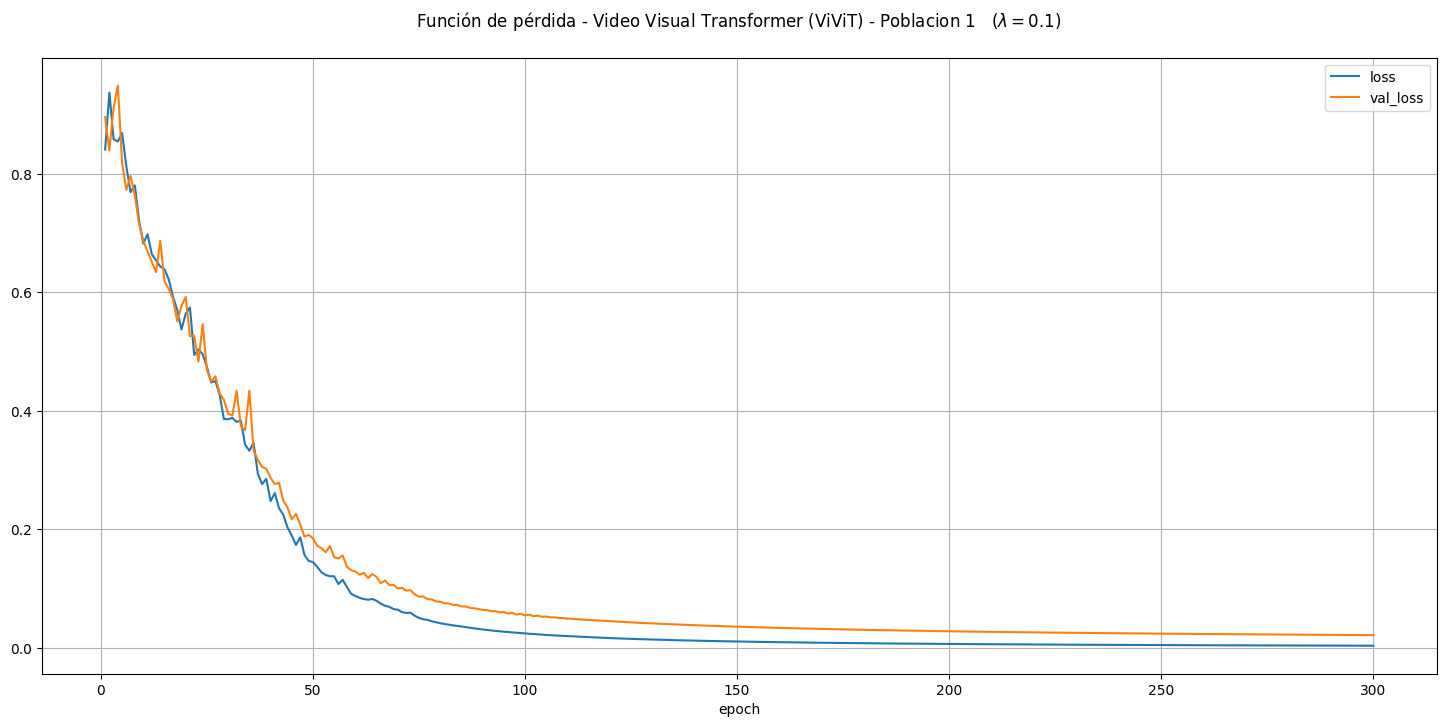

In [ ]:

# GRAFICAMOS LOS RESULTADOS DEL APRENDIZAJE - LOSS (2 clases)
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8), dpi=100)
ax  = plt.subplot(111)
pd.DataFrame(hist).plot(x='epoch', y=['loss','val_loss'], grid=True, ax=ax)
plt.title('Función de pérdida - Video Visual Transformer (ViViT) - Poblacion 1   ($\lambda = 0$.$1$)' + '\n')
plt.show()


# Representamos la ACCURACY (para la discriminación en 2 clases)

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_579/1443924054.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Accuracy - Video Visual Transformer (ViViT) - Poblacion 1   ($\lambda = 0$.$1$)' + '\n')


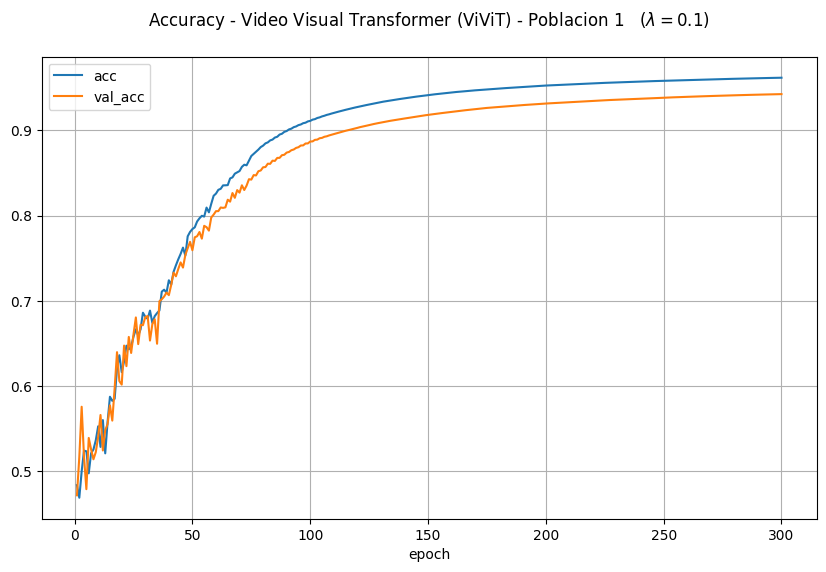

In [ ]:

# GRAFICAMOS LOS RESULTADOS DEL APRENDIZAJE - ACCURACY  (2 agentes)
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=100)
ax  = plt.subplot(111)
pd.DataFrame(hist).plot(x='epoch', y=['acc','val_acc'], grid=True, ax=ax)
plt.title('Accuracy - Video Visual Transformer (ViViT) - Poblacion 1   ($\lambda = 0$.$1$)' + '\n')
plt.show()


# Matriz de Confusión

In [ ]:

# Importamos la librería para obtener la MATRIZ de CONFUSIÓN
# ==========================================================
# Resultados: en una matriz de texto
# ----------------------------------------------------------
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

torch.set_printoptions(precision=2)

X_prueba, y_prueba = next(iter(dataloader['val']))
y_prediccion = model(X_prueba)

y_prob = torch.argmax(softmax(y_prediccion), axis=1)


In [ ]:
from functools import reduce

predicciones  = []
observaciones = []

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b_full in dataloader['val']:
  x_b = x_b.to(DEVICE)

  y_pred = model(x_b) # y_pred has shape (batch_size, num_temporal_tubelets, output_dims, H, W)

  # Adapt y_b_full to match model output's temporal dimension (num_temporal_tubelets)
  y_b_adapted = y_b_full[:, ::model.patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

  # Flatten y_pred for softmax and argmax
  y_pred_flat = y_pred.view(-1, model.output_dims, model.img_size, model.img_size)

  # Get predictions by applying softmax and then argmax to find the most probable class
  y_prob = torch.argmax(softmax(y_pred_flat), axis=1) # (batch_size * num_temporal_tubelets, H, W)

  # Flatten the adapted ground truth for comparison
  y_b_adapted_flat = y_b_adapted.view(-1, model.img_size, model.img_size)

  predicciones.append(list(y_prob.cpu().numpy().flatten()))
  observaciones.append(list(y_b_adapted_flat.cpu().numpy().flatten()))

data_pred = reduce(lambda a, b: a+b, predicciones)
data_obs  = reduce(lambda a, b: a+b, observaciones)

confusion_matrix(data_obs, data_pred)


array([[246513,  18027],
       [    20,  49040]])

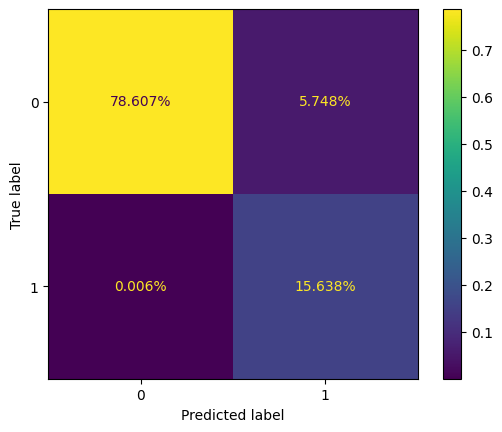

In [ ]:

ConfusionMatrixDisplay.from_predictions(data_obs, data_pred, normalize='all', values_format='.3%')


# **Resultados para discriminación en 4 clases**.

In [ ]:

import pandas as pd

# Duración del ENTRENAMIENTO: 8 minutos (60 Epochs) Casi 97%
pd.DataFrame(hist).to_csv("Training_TRANSFORMER_60Epochs_4000ciclos_85_vs_15.csv", index=None)


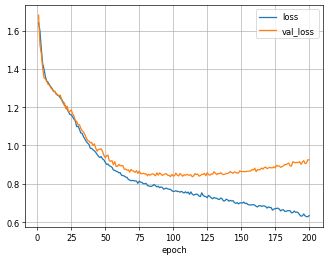

In [ ]:

# GRAFICAMOS LOS RESULTADOS DEL APRENDIZAJE - LOSS (4 clases / 200 epochs)
# =========================================

import matplotlib.pyplot as plt

fig = plt.figure(dpi=60)
#fig = plt.figure(figsize=(10,6))
ax  = plt.subplot(111)
pd.DataFrame(hist).plot(x='epoch', y=['loss','val_loss'], grid=True, ax=ax)
#plt.ylim([0,0.010])
plt.show()


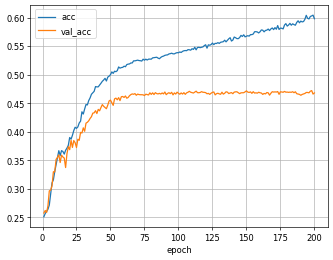

In [ ]:

# GRAFICAMOS LOS RESULTADOS DEL APRENDIZAJE - ACCURACY
# =========================================

import matplotlib.pyplot as plt

fig = plt.figure(dpi=60)
#fig = plt.figure(figsize=(10,6))
ax  = plt.subplot(111)
pd.DataFrame(hist).plot(x='epoch', y=['acc','val_acc'], grid=True, ax=ax)
#plt.ylim([0,0.010])
plt.show()



# EVOLUCIÓN DE LA ACCURACY:
# · Simulación entrenada durante 4000 ciclos: aprox. 96%
# · Simulación entrenada durante 3000 ciclos: aprox. 96%
# · Simulación entrenada durante 2000 ciclos: aprox. 93%


# <font color="brown"><b><u>EVALUACIÓN de RESULTADOS</u></b></font>.

Empleamos matrices de confusión para diseccionar cómo se producen los errores.

In [ ]:

# Importamos la librería para obtener la MATRIZ de CONFUSIÓN
# ==========================================================
# Resultados: en una matriz de texto
# ----------------------------------------------------------
from sklearn.metrics import confusion_matrix

torch.set_printoptions(precision=2)

X_prueba, y_prueba = next(iter(dataloader['val']))
y_prediccion = model(X_prueba)

y_prob = torch.argmax(softmax(y_prediccion), axis=1)
# Podemos visualizar uno de los frames: y_prueba[1] frente a
# su predicción: y_prob[1]

# Los resultados del frame en particular pueden calcularse:
# confusion_matrix(y_prueba[1].flatten().numpy(), y_prob[1].flatten().numpy())


In [ ]:

# Importamos la librería para obtener la MATRIZ de CONFUSIÓN
# ==========================================================
# Resultados: en una matriz gráfica
# ----------------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay

# Agente emocional         --> código: 0
# Agente mutante (traidor) --> código: 1
# --------------------------------------
#ConfusionMatrixDisplay.from_predictions(y_prueba[1].flatten().numpy(), y_prob[1].flatten().numpy())


##1) Probamos con todos los píxeles de los frames (de 28x28) del conjunto de **DATOS de ENTRENAMIENTO**.

In [ ]:

from functools import reduce

predicciones_train  = []
observaciones_train = []

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b in dataloader['train']:
  y_pred = model(x_b)
  y_prob = torch.argmax(softmax(y_pred), axis=1)
  # Se añaden como arrays a la lista, por lo que convertimos previamente a una lista
  # El resultado es una lista de lista, por lo que las reducimos a una sola más abajo
  # (Esto es así porque el procedimiento confusion_matrix sólo opera datos de 1 dimensión)
  predicciones_train.append(list(y_prob.numpy().flatten()))
  observaciones_train.append(list(y_b.numpy().flatten()))

data_pred_train = reduce(lambda a, b: a+b, predicciones_train)
data_obs_train  = reduce(lambda a, b: a+b, observaciones_train)

confusion_matrix(data_obs_train, data_pred_train)


ValueError: Found input variables with inconsistent numbers of samples: [2508800, 125440]

In [ ]:

from functools import reduce

predicciones_train  = []
observaciones_train = []

# Iteramos por el conjunto de datos de Entrenamiento
# -----------------------------------------------
for x_b, y_b_full in dataloader['train']:
  # Move x_b to device (GPU if available)
  x_b = x_b.to(DEVICE)

  y_pred = model(x_b) # y_pred has shape (batch_size, num_temporal_tubelets, output_dims, H, W)

  # Adapt y_b_full to match model output's temporal dimension (num_temporal_tubelets)
  # This aligns the ground truth with the model's temporal predictions.
  # For simplicity, we select the first frame of each 'temporal tubelet' as its representative target.
  y_b_adapted = y_b_full[:, ::patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

  # Flatten y_pred for softmax and argmax, as done in the fit function
  y_pred_flat = y_pred.view(-1, output_dims, img_size, img_size) # (batch_size * num_temporal_tubelets, output_dims, H, W)

  # Get predictions by applying softmax and then argmax to find the most probable class
  y_prob = torch.argmax(softmax(y_pred_flat), axis=1) # (batch_size * num_temporal_tubelets, H, W)

  # Flatten the adapted ground truth for comparison
  y_b_adapted_flat = y_b_adapted.view(-1, img_size, img_size) # (batch_size * num_temporal_tubelets, H, W)

  # Append flattened predictions and observations to their respective lists
  # .cpu() is used to move tensors back to CPU before converting to numpy and then to list
  predicciones_train.append(list(y_prob.cpu().numpy().flatten()))
  observaciones_train.append(list(y_b_adapted_flat.cpu().numpy().flatten()))

data_pred_train = reduce(lambda a, b: a+b, predicciones_train)
data_obs_train  = reduce(lambda a, b: a+b, observaciones_train)

confusion_matrix(data_obs_train, data_pred_train)


array([[317526,  75393,  79195,  89376],
       [137505, 146399,     84,    152],
       [  7935,    268, 343298, 214809],
       [  7314,    212, 144168, 317966]])

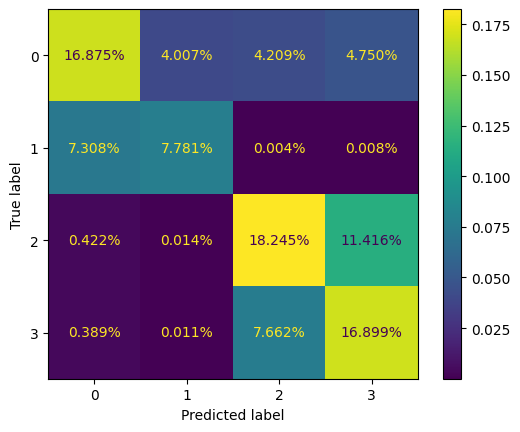

In [ ]:

ConfusionMatrixDisplay.from_predictions(data_obs_train, data_pred_train, normalize='all', values_format='.3%')



##2) Ahora probamos con todos los píxeles de los frames (de 28x28) del conjunto de **DATOS de VALIDACIÓN**.


In [ ]:

from functools import reduce

predicciones  = []
observaciones = []

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b in dataloader['val']:
  y_pred = model(x_b)
  y_prob = torch.argmax(softmax(y_pred), axis=1)
  # Se añaden como arrays a la lista, por lo que convertimos previamente a una lista
  # El resultado es una lista de lista, por lo que las reducimos a una sola más abajo
  # (Esto es así porque el procedimiento confusion_matrix sólo opera datos de 1 dimensión)
  predicciones.append(list(y_prob.numpy().flatten()))
  observaciones.append(list(y_b.numpy().flatten()))

data_pred = reduce(lambda a, b: a+b, predicciones)
data_obs  = reduce(lambda a, b: a+b, observaciones)

confusion_matrix(data_obs, data_pred)


In [ ]:
from functools import reduce

predicciones  = []
observaciones = []

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b_full in dataloader['val']: # Changed y_b to y_b_full
  x_b = x_b.to(DEVICE) # Move to device

  y_pred = model(x_b) # (batch_size, num_temporal_tubelets, output_dims, H, W)

  # Adapt y_b_full to match model output's temporal dimension (num_temporal_tubelets)
  y_b_adapted = y_b_full[:, ::patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

  # Flatten y_pred for softmax and argmax, as done in the fit function
  y_pred_flat = y_pred.view(-1, output_dims, img_size, img_size) # (batch_size * num_temporal_tubelets, output_dims, H, W)

  # Get predictions by applying softmax and then argmax to find the most probable class
  y_prob = torch.argmax(softmax(y_pred_flat), axis=1) # (batch_size * num_temporal_tubelets, H, W)

  # Flatten the adapted ground truth for comparison
  y_b_adapted_flat = y_b_adapted.view(-1, img_size, img_size) # (batch_size * num_temporal_tubelets, H, W)

  predicciones.append(list(y_prob.cpu().numpy().flatten())) # Move to CPU before numpy
  observaciones.append(list(y_b_adapted_flat.cpu().numpy().flatten())) # Move to CPU before numpy

data_pred = reduce(lambda a, b: a+b, predicciones)
data_obs  = reduce(lambda a, b: a+b, observaciones)

confusion_matrix(data_obs, data_pred)


array([[69957, 32747, 17916, 19780],
       [44879, 25519,   164,   138],
       [ 4509,   179, 64134, 72238],
       [ 3906,   165, 53702, 60467]])

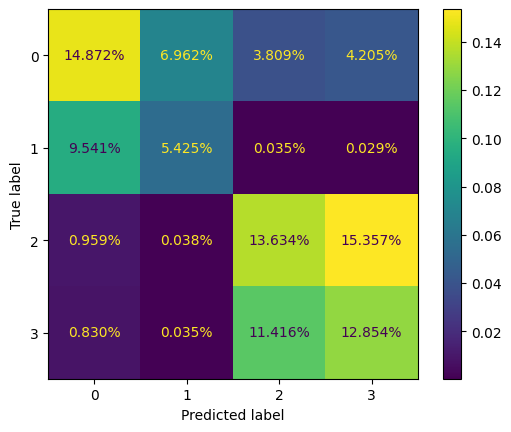

In [ ]:

ConfusionMatrixDisplay.from_predictions(data_obs, data_pred, normalize='all', values_format='.3%')


##Representamos con colores a los agentes mutantes correcta o equivocadamente identificados.

In [ ]:

from sklearn.metrics import confusion_matrix

torch.set_printoptions(precision=2)

X_obs, y_obs = next(iter(dataloader['val']))
y_probab = model(X_obs)
y_predic = torch.argmax(softmax(y_probab), axis=1)

# Utilizamos códigos para representar los colores y así identificar
# mejor a los agentes en la predicción (agentes MUTANTES)
red    = '\033[91m'
green  = '\033[92m'
black  = '\x1b[0m'
# También:
red_bold  = '\x1b[1;02;31m'
green_bold = '\x1b[1;02;32m'
# Con fondo:
red_bold_fondo  = '\x1b[1;02;31;43m'
green_bold_fondo = '\x1b[1;02;32;43m'

frame  = 2
cadena = ''
size_m = 3

for i in range(size):
  for j in range(size):
    if (y_predic[frame,i,j] != y_obs[frame,i,j]) and (y_predic[frame,i,j] == 1):
      cadena += red_bold_fondo + str(y_predic[frame,i,j].numpy()) + black + '  '
    elif (y_predic[frame,i,j] != y_obs[frame,i,j]) and (y_predic[frame,i,j] == 0):
      cadena += red_bold_fondo + '.' + black + '  '
    elif (y_predic[frame,i,j] == y_obs[frame,i,j]) and (y_predic[frame,i,j] == 1):
      cadena += green_bold + str(y_predic[frame,i,j].numpy()) + black + '  '
    else:
      cadena += str(y_predic[frame,i,j].numpy()) + '  '
  cadena += '\n'

print(cadena)


RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [ ]:

import matplotlib.pyplot as plt

# Uno de los frames
# -----------------
plt.imshow(X_obs[1].permute(1,2,0))
plt.show()


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

##Representamos la curva <b>ROC</b>.

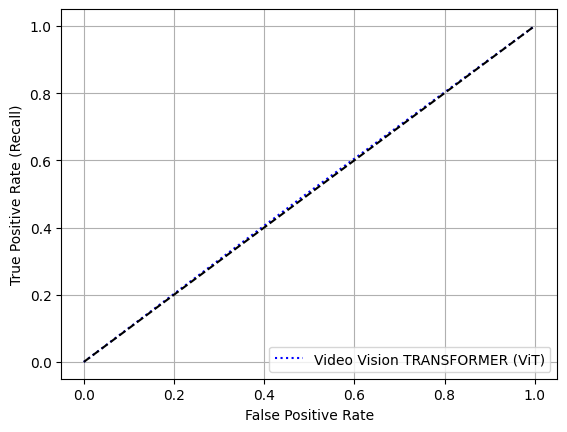

In [ ]:

from sklearn.metrics import roc_curve

# CURVA ROC  (Creo que son 'scores' lo que se le debe pasar
# como segundo argumento. No sé si se puede hacer así)
# ---------------------------------------------------------
fpr, tpr, thresholds = roc_curve(data_obs, data_pred)
#plt.plot(fpr, tpr, 'b:', label='Convolutional Neural Net')
plt.plot(fpr, tpr, 'b:', label='Video Vision TRANSFORMER (ViT)')
plt.plot([0, 1], [0, 1], 'k--')
#plt.axis([0, 1, 0, 1])     # Libro de Aurelien Geron
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()


# <font color="brown"><b><u>ESTRUCTURA del MODELO</u></b></font>.

Vemos el número de parámetros y las capas de las que está compuesto.

In [ ]:
from torchsummary import summary

#print(model)

# EMPLEAR:
# from torchsummary import summary
# summary(your_model, input_size=(channels, H, W))
# -------------------------------------------------

# The model expects an input shape of (batch_size, num_frames, in_chans, img_h, img_w).
# The 'summary' function adds the batch_size, so we need to provide (num_frames, in_chans, img_h, img_w).
# From the notebook context:
num_frames = 40
in_chans = 3
img_size = 28
summary(model, input_size=(num_frames, in_chans, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Rearrange-1          [-1, 40, 16, 147]               0
            Linear-2          [-1, 40, 16, 128]          18,944
    PatchEmbedding-3          [-1, 40, 16, 128]               0
         LayerNorm-4             [-1, 640, 128]             256
            Linear-5             [-1, 640, 128]          16,512
            Linear-6             [-1, 640, 128]          16,512
            Linear-7             [-1, 640, 128]          16,512
            Linear-8             [-1, 640, 128]          16,512
MultiHeadAttention-9             [-1, 640, 128]               0
        LayerNorm-10             [-1, 640, 128]             256
           Linear-11             [-1, 640, 512]          66,048
             ReLU-12             [-1, 640, 512]               0
           Linear-13             [-1, 640, 128]          65,664
 TransformerBlock-14             [-1, 6

# <font color="brown"><b><u>OPTIMIZACIÓN de HIPERPARÁMETROS</u></b></font>.  Utilización del paquete <font color="green"><b>Optuna</b></font>

Hay otras librerías, como las de <b>scikit-learn</b> que implementan métodos de optimización como '<font color="blue">Grid Search</font>' o '<font color="blue">Random Search</font>'.

Optuna utiliza <font color="blue">Optimización bayesiana</font>.

In [ ]:

!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 23.3 MB/s eta 0:00:00


In [ ]:

import optuna

# FUNCIÓN AUXILIAR y CLASE DEL MODELO
# -----------------------------------

def softmax(x):
  return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

# CONSTRUIMOS LA FUNCIÓN QUE ES LLAMADA POR OPTUNA
# ================================================

def objetive(trial):

  # --------------------------------------------------------------------------------
  img_size    =  28  # (se trata de imágenes de 28 x 28)
  patch_size  =   7  # (patch de tamaño 7 x 7)
  in_chans    =   3  # canales de entrada: 1
  output_dims =   2  # (un canal por cada máscara, es decir: clasificación 2 clases)
  embed_dim   = 128  # (proyectamos en un espacio de 128 dimensiones)
  epochs=10
  log_each=1
  # --------------------------------------------------------------------------------
  # BATCH = 30
  # --------------------------------------------------------------------------------


  # PARÁMETROS a optimizar por OPTUNA
  # ------------------------------------------------------
  #n _dim = trial.suggest_int('dimensiones_proyeccion', [128, ])  #
  embed_dim  = 128
  #n_h    = trial.suggest_int('numero_cabezas', [4, 8, 16])
  n_h    = 8
  n_l    = trial.suggest_int('numero_capas', 2, 4)
  # ------------------------------------------------------

  model  = ViT_Segmentation(img_size, patch_size, in_chans,
                          embed_dim = n_dim,
                          n_heads   = n_h,
                          n_layers  = n_l)

  # DEFINIMOS el ENTRENAMIENTO
  # --------------------------
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.8)

  l, acc         = [], []
  val_l, val_acc = [], []

  for e in range(1, epochs+1):
    _l, _acc = [], []
    model.train()  # <------------------------------------------ MODO de ENTRENAMIENTO
    for x_b, y_b in dataloader['train']:
      y_pred = model(x_b)
      loss   = criterion(y_pred, y_b)
      _l.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      y_probas = torch.argmax(softmax(y_pred), axis=1)
      _acc.append(accuracy_score(y_b.numpy(), y_probas.detach().numpy()))

    l.append(np.mean(_l))
    acc.append(np.mean(_acc))
    if not e % log_each:
      print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f}")

    model.eval()  # <------------------------------------------- MODO de EVALUACIÓN
    _l, _acc = [], []
    with torch.no_grad():
      for x_b, y_b in dataloader['val']:
        y_pred = model(x_b)
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())
        y_probas = torch.argmax(softmax(y_pred), axis=1)
        _acc.append(accuracy_score(y_b.numpy(), y_probas.numpy()))
    val_l.append(np.mean(_l))
    val_acc.append(np.mean(_acc))

  RESULTADOS = {'val_acc': val_acc}

  return RESULTADOS['val_acc'][-1]




#Como queremos rastrear valores de un conjunto específico de valores, implementamos  el procedimiento manualmente.

Tarda unas 2 horas (Población 1 - 4000 ciclos y 20 Epochs).

In [ ]:

import numpy as np

# PARÁMETROS FIJOS
# --------------------------------------------------------------------------------
img_size    =  28  # (se trata de imágenes de 28 x 28)
patch_size  =   7  # (patch de tamaño 7 x 7)
in_chans    =   3  # canales de entrada: 1
output_dims =   2  # (un canal por cada máscara, es decir: clasificación 2 clases)
num_epochs=20
# --------------------------------------------------------------------------------
# BATCH = 30
# --------------------------------------------------------------------------------

# PARÁMETROS a optimizar
# ------------------------------------------------------
embed_dims_list = [64, 128, 256]
n_heads_list    = [4, 8, 16]
n_layers_list   = [1,2,3,4]
# ------------------------------------------------------

# GUARDAR RESULTADOS
Resultados = np.zeros((len(n_layers_list), len(embed_dims_list), len(n_heads_list)))

# GRID SEARCH
# -----------
for i, n_l in enumerate(n_layers_list):
  for j, n_dim in enumerate(embed_dims_list):
    for k, n_h in enumerate(n_heads_list):
      model  = ViT_Segmentation(img_size, patch_size, in_chans,
                          embed_dim = n_dim,
                          n_heads   = n_h,
                          n_layers  = n_l)
      hist   = fit(model, dataloader, num_epochs)
      print('prueba: ', n_l, 'capas -> (', n_dim, ',', n_h,')')
      Resultados[i,j,k] = hist['val_acc'][-1]


Epoch 1/20 loss 0.40024 acc 0.58994
Epoch 2/20 loss 0.30229 acc 0.65782
Epoch 3/20 loss 0.19141 acc 0.71713
Epoch 4/20 loss 0.10776 acc 0.78057
Epoch 5/20 loss 0.06563 acc 0.83156
Epoch 6/20 loss 0.04368 acc 0.86591
Epoch 7/20 loss 0.03408 acc 0.88361
Epoch 8/20 loss 0.02872 acc 0.89392
Epoch 9/20 loss 0.02521 acc 0.90064
Epoch 10/20 loss 0.02271 acc 0.90520
Epoch 11/20 loss 0.02082 acc 0.90848
Epoch 12/20 loss 0.01934 acc 0.91088
Epoch 13/20 loss 0.01812 acc 0.91258
Epoch 14/20 loss 0.01709 acc 0.91383
Epoch 15/20 loss 0.01619 acc 0.91461
Epoch 16/20 loss 0.01540 acc 0.91521
Epoch 17/20 loss 0.01468 acc 0.91567
Epoch 18/20 loss 0.01401 acc 0.91603
Epoch 19/20 loss 0.01338 acc 0.91635
Epoch 20/20 loss 0.01280 acc 0.91672
prueba:  1 capas -> ( 64 , 4 )
Epoch 1/20 loss 0.39943 acc 0.59987
Epoch 2/20 loss 0.29641 acc 0.66448
Epoch 3/20 loss 0.17915 acc 0.72446
Epoch 4/20 loss 0.10300 acc 0.78735
Epoch 5/20 loss 0.06236 acc 0.83762
Epoch 6/20 loss 0.04245 acc 0.86983
Epoch 7/20 loss 0.0328

# Representamos gráficamente los resultados

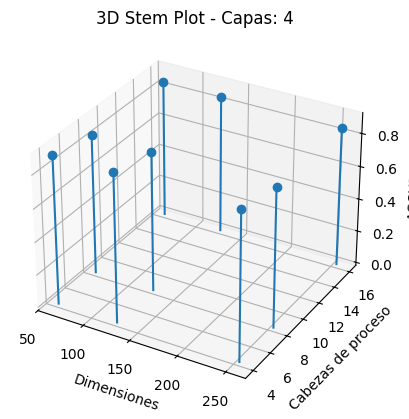

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Valores por CAPA:
# ----------------
X_cat = [64, 128, 256]
Y_cat = [ 4,   8,  16]

# Accuracy (Una matriz con los resultados de cada capa)
# -----------------------------------------------------
Z_2D_1 = Resultados[0,:,:]
Z_2D_2 = Resultados[1,:,:]
Z_2D_3 = Resultados[2,:,:]
Z_2D_4 = Resultados[3,:,:]

fig = plt.figure(dpi=100)
ax  = fig.add_subplot(111, projection='3d')

# Expandimos para que cuadren las dimensiones con un MESHGRID
x_coords, y_coords = np.meshgrid(X_cat, Y_cat)

# Convertimos en 1D con .flatten()
# Con el comando: basefmt=" ", borramos la linea roja que sale en la base
#   y que contecta todos los puntos entre sí
ax.stem(x_coords.flatten(), y_coords.flatten(), Z_2D_4.flatten(), basefmt=" ")

ax.set_xlabel('Dimensiones')
ax.set_ylabel('Cabezas de proceso')
ax.set_zlabel('ACCURACY')
ax.set_title('3D Stem Plot - Capas: 4')

plt.show()


In [ ]:

import numpy as np

np.savetxt("Matriz_GridSearch_Transformer_1.csv", Resultados[0,:,:], delimiter=",")
np.savetxt("Matriz_GridSearch_Transformer_2.csv", Resultados[1,:,:], delimiter=",")
np.savetxt("Matriz_GridSearch_Transformer_3.csv", Resultados[2,:,:], delimiter=",")
np.savetxt("Matriz_GridSearch_Transformer_4.csv", Resultados[3,:,:], delimiter=",")


In [ ]:

import numpy as np
import pandas as pd

m1 = pd.read_csv("Matriz_GridSearch_Transformer_1.csv", header=None)
m2 = pd.read_csv("Matriz_GridSearch_Transformer_2.csv", header=None)
m3 = pd.read_csv("Matriz_GridSearch_Transformer_3.csv", header=None)
m4 = pd.read_csv("Matriz_GridSearch_Transformer_4.csv", header=None)

# Sustituimos los valores en los que se atascaba por 0
# Cuando sale NaN, se queda fijo alrededor de 0.84
m1 = pd.DataFrame(m1.values, index=["4", "8", "16"], columns=["64", "128", "256"])
m2 = pd.DataFrame(m2.values, index=["4", "8", "16"], columns=["64", "128", "256"])
m3 = pd.DataFrame(m3.values, index=["4", "8", "16"], columns=["64", "128", "256"])
m4 = pd.DataFrame(m4.values, index=["4", "8", "16"], columns=["64", "128", "256"])
m4


,64,128,256
4,0.901668,0.905408,0.899469
8,0.848491,0.848491,0.848491
16,0.848491,0.848491,0.848491


In [ ]:

m4.values.flatten()


array([0.90166761, 0.90540832, 0.89946932, 0.84849143, 0.84849143,
       0.84849143, 0.84849143, 0.84849143, 0.84849143])

# AHORA GRAFICAMOS PONIENDO A 0 LOS TRAINING PROBLEMÁTICOS

(Donde la loss empieza a poner: NaN)

# LAYERS: 1

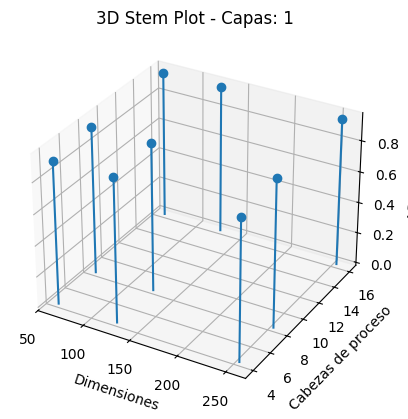

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Valores por CAPA:
# ----------------
X_cat = [64, 128, 256]
Y_cat = [ 4,   8,  16]

# Accuracy (Una matriz con los resultados de cada capa)
# -----------------------------------------------------
Z_2D_1 = m1.values

fig = plt.figure(dpi=100)
ax  = fig.add_subplot(111, projection='3d')

# Expandimos para que cuadren las dimensiones con un MESHGRID
x_coords, y_coords = np.meshgrid(X_cat, Y_cat)

# Convertimos en 1D con .flatten()
# Con el comando: basefmt=" ", borramos la linea roja que sale en la base
#   y que contecta todos los puntos entre sí
ax.stem(x_coords.flatten(), y_coords.flatten(), Z_2D_1.flatten(), basefmt=" ")

ax.set_xlabel('Dimensiones')
ax.set_ylabel('Cabezas de proceso')
ax.set_zlabel('ACCURACY')
ax.set_title('3D Stem Plot - Capas: 1')

plt.show()


# LAYERS: 2

In [ ]:

m2.loc["16",  "64"] = 0.0
m2.loc["16", "128"] = 0.0
m2.loc["16", "256"] = 0.0
m2


,64,128,256
4,0.907783,0.898934,0.910634
8,0.944872,0.951032,0.953582
16,0.000000,0.000000,0.000000


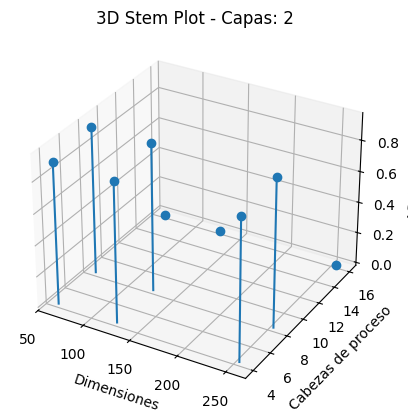

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Valores por CAPA:
# ----------------
X_cat = [64, 128, 256]
Y_cat = [ 4,   8,  16]

# Accuracy (Una matriz con los resultados de cada capa)
# -----------------------------------------------------
Z_2D_2 = m2.values

fig = plt.figure(dpi=100)
ax  = fig.add_subplot(111, projection='3d')

# Expandimos para que cuadren las dimensiones con un MESHGRID
x_coords, y_coords = np.meshgrid(X_cat, Y_cat)

# Convertimos en 1D con .flatten()
# Con el comando: basefmt=" ", borramos la linea roja que sale en la base
#   y que contecta todos los puntos entre sí
ax.stem(x_coords.flatten(), y_coords.flatten(), Z_2D_2.flatten(), basefmt=" ")

ax.set_xlabel('Dimensiones')
ax.set_ylabel('Cabezas de proceso')
ax.set_zlabel('ACCURACY')
ax.set_title('3D Stem Plot - Capas: 2')

plt.show()


# LAYERS: 3

In [ ]:

m3.loc["16",  "64"] = 0.0
m3.loc["16", "128"] = 0.0
m3.loc["16", "256"] = 0.0
m3


,64,128,256
4,0.899434,0.895879,0.909796
8,0.946207,0.948973,0.954238
16,0.000000,0.000000,0.000000


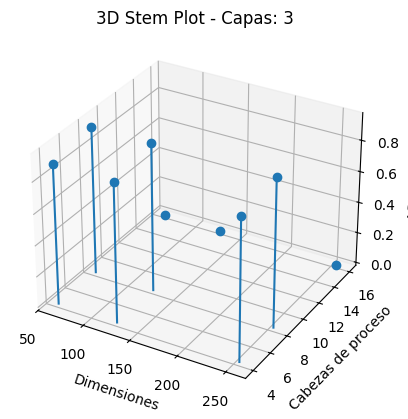

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Valores por CAPA:
# ----------------
X_cat = [64, 128, 256]
Y_cat = [ 4,   8,  16]

# Accuracy (Una matriz con los resultados de cada capa)
# -----------------------------------------------------
Z_2D_3 = m3.values

fig = plt.figure(dpi=100)
ax  = fig.add_subplot(111, projection='3d')

# Expandimos para que cuadren las dimensiones con un MESHGRID
x_coords, y_coords = np.meshgrid(X_cat, Y_cat)

# Convertimos en 1D con .flatten()
# Con el comando: basefmt=" ", borramos la linea roja que sale en la base
#   y que contecta todos los puntos entre sí
ax.stem(x_coords.flatten(), y_coords.flatten(), Z_2D_3.flatten(), basefmt=" ")

ax.set_xlabel('Dimensiones')
ax.set_ylabel('Cabezas de proceso')
ax.set_zlabel('ACCURACY')
ax.set_title('3D Stem Plot - Capas: 3')

plt.show()


# LAYERS: 4

In [ ]:
m4.loc[ "8",  "64"] = 0.0
m4.loc[ "8", "128"] = 0.0
m4.loc[ "8", "256"] = 0.0
m4.loc["16",  "64"] = 0.0
m4.loc["16", "128"] = 0.0
m4.loc["16", "256"] = 0.0
m4

,64,128,256
4,0.901668,0.905408,0.899469
8,0.000000,0.000000,0.000000
16,0.000000,0.000000,0.000000


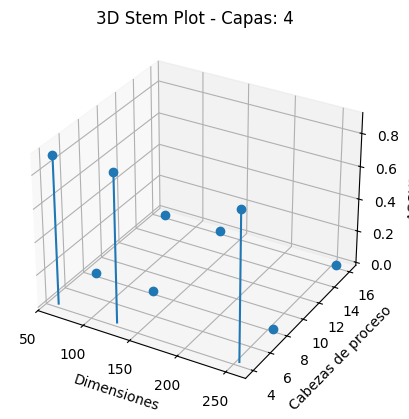

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Valores por CAPA:
# ----------------
X_cat = [64, 128, 256]
Y_cat = [ 4,   8,  16]

# Accuracy (Una matriz con los resultados de cada capa)
# -----------------------------------------------------
Z_2D_4 = m4.values

fig = plt.figure(dpi=100)
ax  = fig.add_subplot(111, projection='3d')

# Expandimos para que cuadren las dimensiones con un MESHGRID
x_coords, y_coords = np.meshgrid(X_cat, Y_cat)

# Convertimos en 1D con .flatten()
# Con el comando: basefmt=" ", borramos la linea roja que sale en la base
#   y que contecta todos los puntos entre sí
ax.stem(x_coords.flatten(), y_coords.flatten(), Z_2D_4.flatten(), basefmt=" ")

ax.set_xlabel('Dimensiones')
ax.set_ylabel('Cabezas de proceso')
ax.set_zlabel('ACCURACY')
ax.set_title('3D Stem Plot - Capas: 4')

plt.show()


In [ ]:

estudio = optuna.create_study(direction='maximize')
estudio.optimize(objetive, n_trials=4)

print(estudio.best_params)


In [ ]:

embed_dims_list = [64, 128, 258]
n_heads_list   = [4, 8, 16]
n_layers_list  = [1,2,3,4]

# PARÁMETROS a optimizar
# ------------------------------------------------------

# GUARDAR RESULTADOS
Resultados = np.zeros((3,3,3))

cont_1 = 0
cont_2 = 0
cont_3 = 0

# GRID SEARCH
# -----------
for n_layer_val in n_layers_list:
  for embed_dim_val in embed_dims_list:
    for n_head_val in n_heads_list:
      print(f"n_l: {n_layer_val}, n_dim: {embed_dim_val}, n_h: {n_head_val}")

n_l: 1, n_dim: 64, n_h: 4
n_l: 1, n_dim: 64, n_h: 8
n_l: 1, n_dim: 64, n_h: 16
n_l: 1, n_dim: 128, n_h: 4
n_l: 1, n_dim: 128, n_h: 8
n_l: 1, n_dim: 128, n_h: 16
n_l: 1, n_dim: 258, n_h: 4
n_l: 1, n_dim: 258, n_h: 8
n_l: 1, n_dim: 258, n_h: 16
n_l: 2, n_dim: 64, n_h: 4
n_l: 2, n_dim: 64, n_h: 8
n_l: 2, n_dim: 64, n_h: 16
n_l: 2, n_dim: 128, n_h: 4
n_l: 2, n_dim: 128, n_h: 8
n_l: 2, n_dim: 128, n_h: 16
n_l: 2, n_dim: 258, n_h: 4
n_l: 2, n_dim: 258, n_h: 8
n_l: 2, n_dim: 258, n_h: 16
n_l: 3, n_dim: 64, n_h: 4
n_l: 3, n_dim: 64, n_h: 8
n_l: 3, n_dim: 64, n_h: 16
n_l: 3, n_dim: 128, n_h: 4
n_l: 3, n_dim: 128, n_h: 8
n_l: 3, n_dim: 128, n_h: 16
n_l: 3, n_dim: 258, n_h: 4
n_l: 3, n_dim: 258, n_h: 8
n_l: 3, n_dim: 258, n_h: 16
n_l: 4, n_dim: 64, n_h: 4
n_l: 4, n_dim: 64, n_h: 8
n_l: 4, n_dim: 64, n_h: 16
n_l: 4, n_dim: 128, n_h: 4
n_l: 4, n_dim: 128, n_h: 8
n_l: 4, n_dim: 128, n_h: 16
n_l: 4, n_dim: 258, n_h: 4
n_l: 4, n_dim: 258, n_h: 8
n_l: 4, n_dim: 258, n_h: 16


In [ ]:

import numpy as np




In [ ]:

import pandas as pd

df_prueba_1a = pd.DataFrame([[2,3,4],[2,3,6],[6,7,8]], columns=["g0", "g1", "g783"])
df_prueba_1a


,g0,g1,g783
0,2,3,4
1,2,3,6
2,6,7,8



#**Probamos con versiones ya programadas, para ver si funciona.**

<figure>
<center>
<img src='https://github.com/oscarserc/IMAGENES/blob/main/Hugging_Face_1a.png?raw=true' width="650"/>
<figcaption></font></figcaption></center>
</figure>


In [ ]:

!pip install transformers


In [ ]:

from transformers import VivitModel, VivitConfig
from transformers import Trainer

configuration = VivitConfig(image_size = 28, tubelet_size = [4, 7, 7],
                            num_channels = 3, hidden_size = 128, num_hidden_layers = 3,
                            hidden_act = 'relu')

model = VivitModel(configuration)

trainer = Trainer(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"]
)

trainer.train()


# Empleamos la otra clase más detallada de **SKLEARN** sobre métricas.


#**<font color="green">CLASIFICATION REPORT.</font>**



Results for (LSTM) model with num_frames=40:
  Final Training Loss: 0.0039
  Final Training Accuracy: 0.9617
  Final Validation Loss: 0.0217
  Final Validation Accuracy: 0.9425


 RESUMEN GLOBAL
----------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    264540
           1       0.98      0.99      0.99     49060

    accuracy                           1.00    313600
   macro avg       0.99      0.99      0.99    313600
weighted avg       1.00      1.00      1.00    313600

  Confusion Matrix:
--------------------
    [263723, 817]
    [398, 48662]


  Class 1 F1-score: 0.9877
  Validation ROC AUC: 0.9998




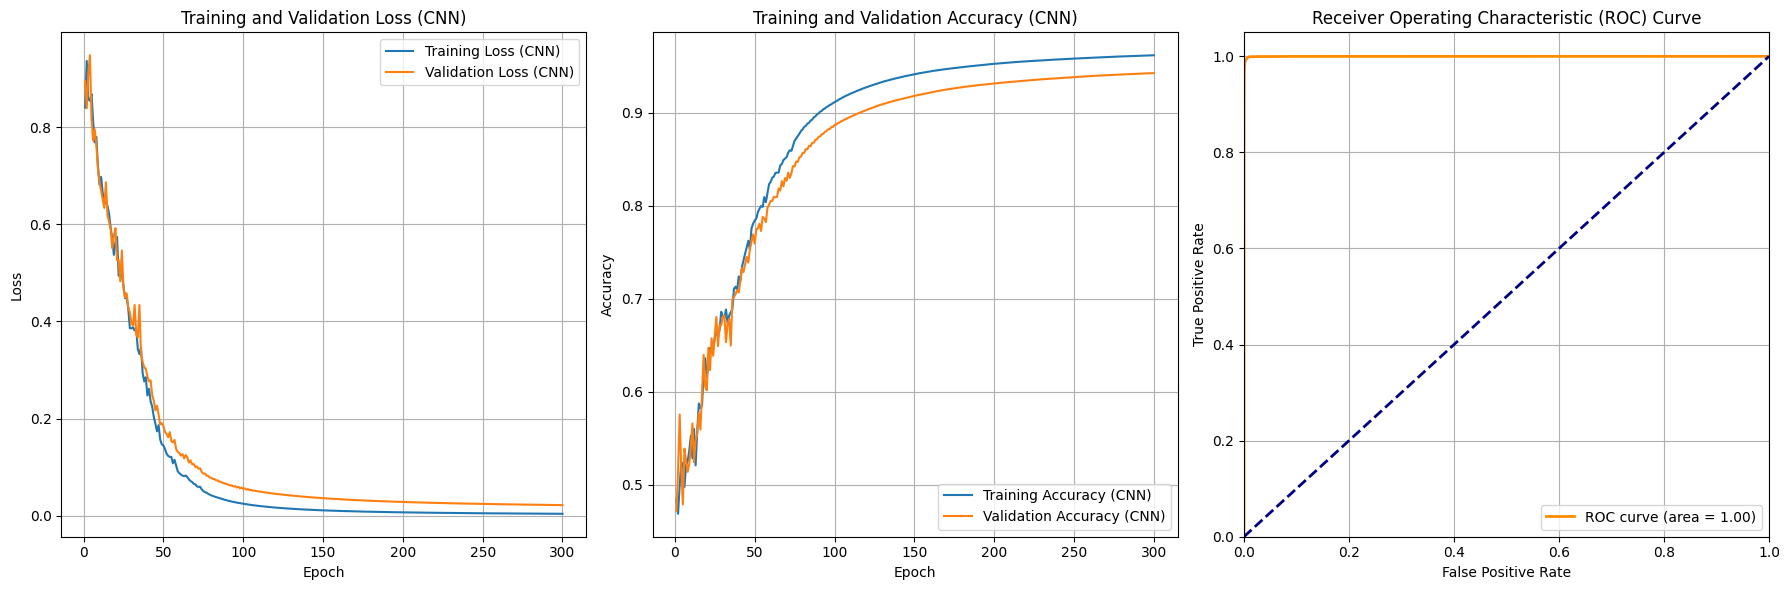

In [ ]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

# PONEMOS EL MODELO EN MODO EVALUACIÓN - dejamos explícitamente congelados
# los valores de los parámetros
model.eval()

predicciones  = []
observaciones = []
scores        = [] # for ROC curve, probabilities of the positive class

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b_full in dataloader['val']: # y_b_full has shape (batch_size, num_frames, H, W)
  x_b = x_b.to(DEVICE)

  # Model prediction output shape: (batch_size, num_temporal_tubelets, output_dims, H, W)
  y_pred_model_output = model(x_b)

  # Adapt y_b_full to match model output's temporal dimension (num_temporal_tubelets)
  # This aligns the ground truth with the model's temporal predictions.
  y_b_adapted = y_b_full[:, ::model.patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

  # Reshape model output to (N, C, H, W) where N = batch_size * num_temporal_tubelets
  # This is consistent with what CrossEntropyLoss expects and simplifies softmax/argmax
  y_pred_flat_for_metrics = y_pred_model_output.view(
      -1, model.output_dims, model.img_size, model.img_size
  ) # Shape: (batch_size * num_temporal_tubelets, output_dims, H, W)

  # Get predicted classes (argmax over the class dimension, which is dim=1)
  # Use torch.nn.functional.softmax for correct dimension application
  y_prob_batch = torch.argmax(F.softmax(y_pred_flat_for_metrics, dim=1), dim=1)
  # Shape of y_prob_batch: (batch_size * num_temporal_tubelets, H, W)

  # Get probabilities for the positive class (class 1) for ROC curve
  y_scores_batch = F.softmax(y_pred_flat_for_metrics, dim=1)[:, 1, :, :]
  # Shape of y_scores_batch: (batch_size * num_temporal_tubelets, H, W)

  # Flatten all for sklearn metrics
  predicciones.append(list(y_prob_batch.cpu().numpy().flatten()))
  observaciones.append(list(y_b_adapted.cpu().numpy().flatten()))
  scores.append(list(y_scores_batch.cpu().detach().numpy().flatten()))

data_pred = reduce(lambda a, b: a+b, predicciones)
data_obs  = reduce(lambda a, b: a+b, observaciones)
data_scores = reduce(lambda a, b: a+b, scores)


# MATRIZ DE CONFUSIÓN
# -------------------
cm = confusion_matrix(data_obs, data_pred)

# INFORME de CLASIFICACIÓN
# ------------------------
cr = classification_report(data_obs, data_pred, output_dict=True, zero_division=0)

# CURVA ROC
# ---------
fpr, tpr, thresholds = [], [], []
roc_auc = 0.0
# Nos aseguramos de que las clases están presentes
if 1 in np.unique(data_obs) and len(np.unique(data_pred)) > 1:
    fpr, tpr, thresholds = roc_curve(data_obs, data_scores)
    roc_auc = auc(fpr, tpr)
else:
    print(f"ATENCIÓN: Clase 1 no está presente.")

# Guardamos los resultados del modelo LSTM
# ----------------------------------------
model_eval_results = {
    'training_history': hist,
    'confusion_matrix': cm.tolist(),
    'classification_report': cr,
    'roc_curve_data': {
        'fpr': fpr.tolist() if isinstance(fpr, np.ndarray) else fpr,
        'tpr': tpr.tolist() if isinstance(tpr, np.ndarray) else tpr,
        'auc': roc_auc
    }
}

# Print results for this single model evaluation
print(f"\nResults for (LSTM) model with num_frames=40:")
print(f"  Final Training Loss: {model_eval_results['training_history']['loss'][-1]:.4f}")
print(f"  Final Training Accuracy: {model_eval_results['training_history']['acc'][-1]:.4f}")
print(f"  Final Validation Loss: {model_eval_results['training_history']['val_loss'][-1]:.4f}")
print(f"  Final Validation Accuracy: {model_eval_results['training_history']['val_acc'][-1]:.4f}")
print("\n")

print(f" RESUMEN GLOBAL")
print(f"----------------")
cr2 = classification_report(data_obs, data_pred, output_dict=False, zero_division=0)
print(cr2)

print("  Confusion Matrix:")
print(f"--------------------")
for row in model_eval_results['confusion_matrix']:
    print(f"    {row}")
print(f"\n")

print(f"  Class 1 F1-score: {model_eval_results['classification_report']['1']['f1-score']:.4f}")
if model_eval_results['roc_curve_data']['auc'] is not None:
    print(f"  Validation ROC AUC: {model_eval_results['roc_curve_data']['auc']:.4f}")
else:
    print("  Validation ROC AUC: N/A")
print(f"\n")

# Optional: Plotting results for comparison
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns
# Plotting for the single model's validation loss
history = model_eval_results['training_history']
plt.plot(history['epoch'], history['loss'], label='Training Loss (CNN)')
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss (CNN)')
plt.title('Training and Validation Loss (CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns
# Plotting for the single model's validation accuracy
history = model_eval_results['training_history']
plt.plot(history['epoch'], history['acc'], label='Training Accuracy (CNN)')
plt.plot(history['epoch'], history['val_acc'], label='Validation Accuracy (CNN)')
plt.title('Training and Validation Accuracy (CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3) # Added subplot for ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

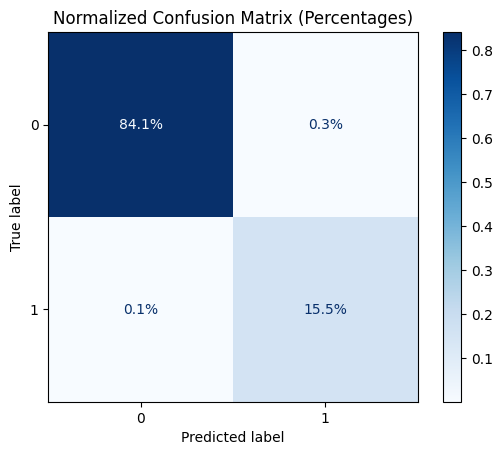

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure data_obs and data_pred are available from previous execution if not re-run
# If this cell is run independently, these variables would need to be re-computed.

plt.figure(figsize=(8, 6)) # Adjust figure size for better visibility
ConfusionMatrixDisplay.from_predictions(data_obs, data_pred, normalize='all', values_format='.1%', cmap='Blues')
plt.title('Normalized Confusion Matrix (Percentages)')
plt.show()

In [ ]:
from functools import reduce
import torch.nn.functional as F # Import F for functional API

predicciones  = []
observaciones = []

# Iteramos por el conjunto de datos de Validación
# -----------------------------------------------
for x_b, y_b_full in dataloader['val']:
  x_b = x_b.to(DEVICE)

  y_pred = model(x_b) # y_pred has shape (batch_size, num_temporal_tubelets, output_dims, H, W)

  # Adapt y_b_full to match model output's temporal dimension (num_temporal_tubelets)
  y_b_adapted = y_b_full[:, ::model.patch_time, :, :] # (batch_size, num_temporal_tubelets, H, W)

  # Flatten y_pred for softmax and argmax
  y_pred_flat = y_pred.view(-1, model.output_dims, model.img_size, model.img_size)

  # Get predictions by applying softmax and then argmax to find the most probable class
  # CORRECTED: Using F.softmax along dim=1 (class dimension)
  y_prob = torch.argmax(F.softmax(y_pred_flat, dim=1), axis=1) # (batch_size * num_temporal_tubelets, H, W)

  # Flatten the adapted ground truth for comparison
  y_b_adapted_flat = y_b_adapted.view(-1, model.img_size, model.img_size)

  predicciones.append(list(y_prob.cpu().numpy().flatten()))
  observaciones.append(list(y_b_adapted_flat.cpu().numpy().flatten()))

data_pred = reduce(lambda a, b: a+b, predicciones)
data_obs  = reduce(lambda a, b: a+b, observaciones)

confusion_matrix(data_obs, data_pred)

array([[263723,    817],
       [   398,  48662]])

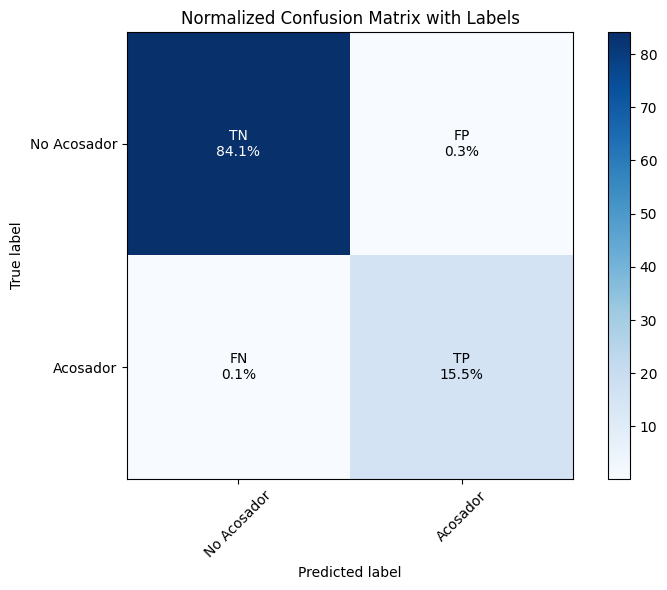

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Obtenemos los conteos en bruto de la Matriz de Confusión
cm_counts = confusion_matrix(data_obs, data_pred)

# Normalize the confusion matrix to get percentages
# Normalizamos la Matriz de Confusión para obtener porcentajes
cm_normalized = cm_counts.astype('float') / cm_counts.sum() * 100

# Definimos etiquetas para las celdas de la Matriz de Confusión
labels = [['TN', 'FP'], ['FN', 'TP']]

# Define class labels for rows and columns
class_names = ['No Acosador', 'Acosador']

plt.figure(figsize=(8, 6))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión normalizada (con etiquetas)')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Ponemos anotados: porcentajes junto a etiquetas
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        # Texto con el porcentaje
        percent_text = f'{cm_normalized[i, j]:.1f}%'
        # Etiqueta: (TN, FP, FN, TP)
        label_text = labels[i][j]

        # Lo presentamos dentro de la celda
        # Usamos un salto de linea y ponemos la etiqueta debajo
        text_to_display = f'{label_text}\n{percent_text}'

        plt.text(j, i, text_to_display, ha='center', va='center',
                 color='white' if cm_normalized[i, j] > cm_normalized.max() / 2 else 'black')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()
